In [2]:
import numpy as np
import pandas as pd
import ast
import json
import os


import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset

In [3]:
TRAIN_PATH = "Data_path/data/data/train"
TEST_PATH =  "Data_path/data/data/test"
LABELS = "Data_path/labeled_anomalies.csv"

In [4]:
df_anomalies = pd.read_csv(LABELS)
df_anomalies.info()
df_anomalies.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   chan_id            82 non-null     object
 1   spacecraft         82 non-null     object
 2   anomaly_sequences  82 non-null     object
 3   class              82 non-null     object
 4   num_values         82 non-null     int64 
dtypes: int64(1), object(4)
memory usage: 3.3+ KB


,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505
1,S-1,SMAP,"[[5300, 5747]]",[point],7331
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[contextual, contextual]",8516
3,E-2,SMAP,"[[5598, 6995]]",[point],8532
4,E-3,SMAP,"[[5094, 8306]]",[point],8307
5,E-4,SMAP,"[[5450, 8261]]",[point],8354
6,E-5,SMAP,"[[5600, 5920]]",[point],8294
7,E-6,SMAP,"[[5610, 5675]]",[point],8300
8,E-7,SMAP,"[[5394, 5674]]",[point],8310
9,E-8,SMAP,"[[5400, 6022]]",[point],8532


Description of labels:

- **channel_id** is the id related to a telemetry acquired by spacecraft/staellite;
- **spacecraft** could be SMAP or MSL;
- **anomaly_sequence** is telling windows corresponding to an anomalies inside that telemetry;
- **class** is telling which type of anomaly is: a *point anomaly* can be identified by properly set alarms or distance-based methods that ignore temporal information, *contextual* require more complex methodologies such as LSTMs or Hierarchical Temporal Memory (HTM) approaches;
- **num_values** is telling how many timestamps of observations the telemetry has.

Description of train/test:
In practice, each channel of train/test is a telemetry, and each telemetry is a **temporal matrix** containing T(num_values) x 25(channels of each variable) samples. 

**However, the first channel (channel 0) is the main one capturing the signal while other are auxilisry channels recording, for instace, commands given to satellite, hence all values inside other channels are almost always 0.**

In [5]:
df_SMAP_anomalies = df_anomalies[df_anomalies['spacecraft'] == 'SMAP']
print(len(df_SMAP_anomalies['chan_id'].unique()))

54


Below, we just want to visualize an example of anomaly on channel 0 of a random telemetry.

Selected telemetry: E-8
Anomaly of telemetry: [[5400 6022]]


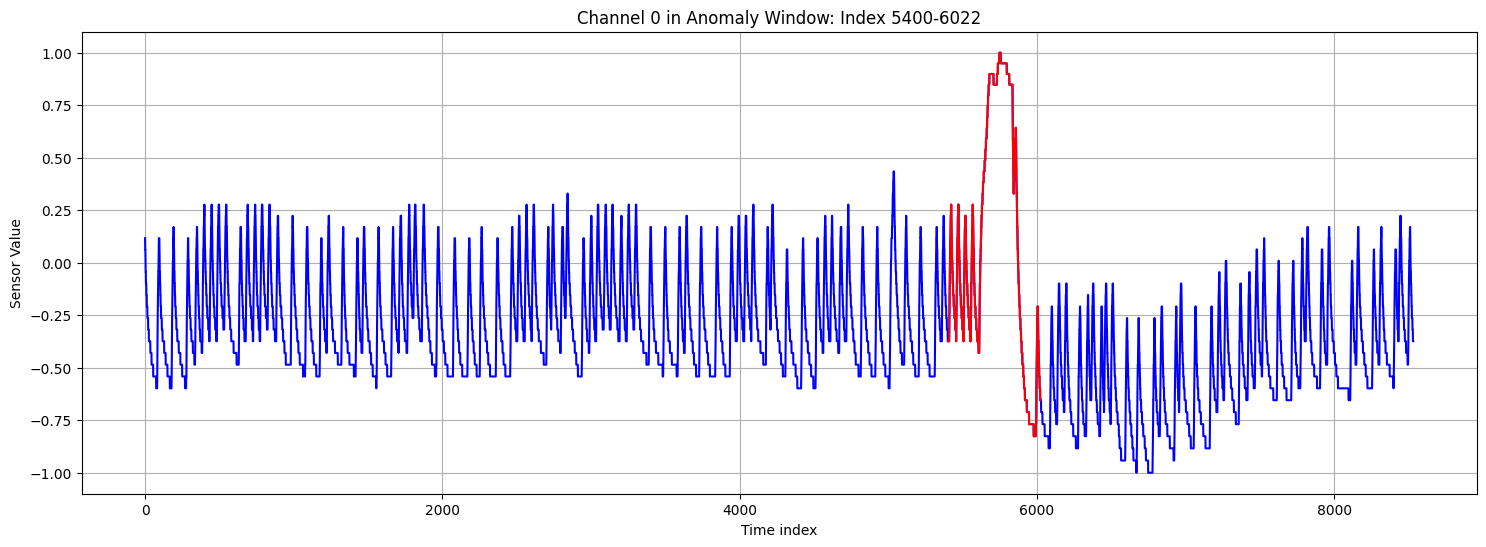

In [6]:
np.random.seed(10)
telemetry_pos = np.random.randint(0,54)
telemetry_name = df_SMAP_anomalies['chan_id'].iloc[telemetry_pos]
print(f'Selected telemetry: {telemetry_name}')

test_data = np.load(TEST_PATH + '/' + telemetry_name + '.npy')

anomalies = df_SMAP_anomalies[df_SMAP_anomalies['chan_id'] == telemetry_name]['anomaly_sequences'].values[0]
anomaly = np.fromstring(anomalies.replace("[", "").replace("]", ""),sep=",",dtype=int).reshape(-1, 2)
print(f'Anomaly of telemetry: {anomaly}')

#just to plot
anomaly_start,anomaly_end = (anomaly[0][0],anomaly[0][1]) if len(anomaly) <= 1 else (anomaly[-1][0],anomaly[-1][1])

plt.figure(figsize=(18,6))

time_indices_anomlay = np.arange(anomaly_start,anomaly_end+1)
time_indices = np.arange(test_data.shape[0])

channel_0_data_anomaly = test_data[anomaly_start:anomaly_end+1,0]
channel_0_data = test_data[:,0]

plt.plot(time_indices,channel_0_data,color='blue')
plt.plot(time_indices_anomlay,channel_0_data_anomaly,color='red')
plt.title(f"Channel 0 in Anomaly Window: Index {anomaly_start}-{anomaly_end}")
plt.xlabel('Time index')
plt.ylabel('Sensor Value')
plt.grid(True)

plt.show()

The one reported, is one of anomalies classified as "contextual" as its behavior is anomalous if compared within the context, but not all anomalies are in this way in this dataset.

Selected telemetry: R-1
Anomaly of telemetry: [[4510 4590]]


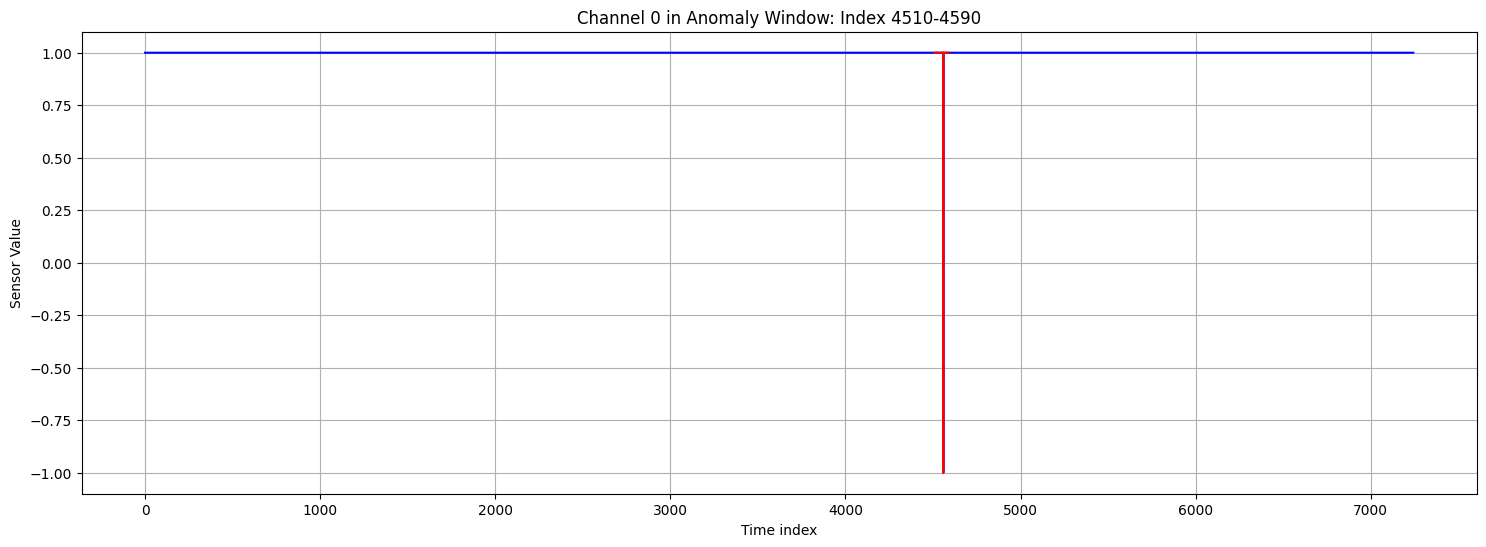

In [7]:
np.random.seed(4)
telemetry_pos = np.random.randint(0,54)
telemetry_name = df_SMAP_anomalies['chan_id'].iloc[telemetry_pos]
print(f'Selected telemetry: {telemetry_name}')

test_data = np.load(TEST_PATH + '/' + telemetry_name + '.npy')

anomalies = df_SMAP_anomalies[df_SMAP_anomalies['chan_id'] == telemetry_name]['anomaly_sequences'].values[0]
anomaly = np.fromstring(anomalies.replace("[", "").replace("]", ""),sep=",",dtype=int).reshape(-1, 2)
print(f'Anomaly of telemetry: {anomaly}')

#just to plot
anomaly_start,anomaly_end = (anomaly[0][0],anomaly[0][1]) if len(anomaly) <= 1 else (anomaly[-1][0],anomaly[-1][1])

plt.figure(figsize=(18,6))

time_indices_anomlay = np.arange(anomaly_start,anomaly_end+1)
time_indices = np.arange(test_data.shape[0])

channel_0_data_anomaly = test_data[anomaly_start:anomaly_end+1,0]
channel_0_data = test_data[:,0]

plt.plot(time_indices,channel_0_data,color='blue')
plt.plot(time_indices_anomlay,channel_0_data_anomaly,color='red')
plt.title(f"Channel 0 in Anomaly Window: Index {anomaly_start}-{anomaly_end}")
plt.xlabel('Time index')
plt.ylabel('Sensor Value')
plt.grid(True)

plt.show()

This one, is what is called "point" anomaly and it is easy to observe that the problem mainly relies on the value of the observed telemetry in a certain timestamp.

Our all around pipeline will be:\
START: test raw\
→ sliding windows\
→ prediction\
→ prediction errors\
→ smoothing errors\
→ thresholding\
→ anomaly buffer\
→ pruning / grouping sequences

## PREPROCESSING

The SMAP dataset is composed of multiple telemetry channels, each corresponding to a specific monitored signal from the Soil Moisture Active Passive satellite system. Each channel is stored as a multivariate time series with 25 features. The first feature represents the main telemetry signal to be modeled and forecasted, while the remaining 24 features represent auxiliary command-related variables. These command variables provide operational context: they describe external inputs or discrete system states that may influence the evolution of the main telemetry signal.

For this reason, the anomaly detection task is naturally framed as a forecasting problem. Given the recent history of the telemetry signal and the associated command variables, the model learns to predict the future behavior of the main signal. An anomaly is then identified when the observed signal deviates significantly from the expected behavior predicted under the current command context.

In this setting, a point anomaly can be interpreted as an isolated telemetry value that is physically unusual by itself, independently of the surrounding temporal context. For example, this may correspond to a sudden spike, drop, or value that lies far outside the usual operating range of the signal.

A contextual anomaly is instead a value that may not be abnormal in absolute terms, but becomes abnormal given the temporal and operational context. For example, a certain telemetry value may be acceptable under one command configuration, but unexpected when the command variables indicate a different operating condition. This interpretation is necessarily subjective, because the dataset does not provide a direct physical explanation for each labeled anomaly; the distinction is inferred from the structure of the data and from the forecasting-based anomaly detection setup.

In [8]:
smap_labels = df_SMAP_anomalies.copy()
smap_channels_ids = sorted(smap_labels['chan_id'].unique())

train_summary = []

for ch in smap_channels_ids:
    path = TRAIN_PATH + '/' + ch + '.npy'
    X = np.load(path)
    
    feature_std = np.std(X, axis=0)
    
    train_summary.append({
        "channel_id": ch,
        "train_len": X.shape[0],
        "n_features": X.shape[1],
        "nan_count": int(np.isnan(X).sum()),
        "inf_count": int(np.isinf(X).sum()),
        "constant_features": int((feature_std == 0).sum()),
        "min": float(np.nanmin(X)),
        "max": float(np.nanmax(X)),
        "mean": float(np.nanmean(X)),
        "std": float(np.nanstd(X)),
    })

train_summary_df = pd.DataFrame(train_summary)
train_summary_df

,channel_id,train_len,n_features,nan_count,inf_count,constant_features,min,max,mean,std
0,A-1,2880,25,0,0,6,0.00,1.0,0.061654,0.240444
1,A-2,2648,25,0,0,7,-1.00,1.0,0.023143,0.186151
2,A-3,2736,25,0,0,7,-1.00,1.0,0.023542,0.173959
3,A-4,2690,25,0,0,7,-1.00,1.0,0.025349,0.163677
4,A-5,705,25,0,0,14,-1.00,1.0,-0.028584,0.224864
5,A-6,682,25,0,0,14,-1.00,1.0,-0.021383,0.200291
6,A-7,2879,25,0,0,15,-1.00,1.0,-0.011630,0.103913
7,A-8,762,25,0,0,15,-1.00,1.0,-0.007294,0.206191
8,A-9,762,25,0,0,15,-1.00,1.0,0.012211,0.204854
9,B-1,2435,25,0,0,13,-1.00,1.0,-0.035992,0.206671


The preliminary inspection of the SMAP training files shows that all channels contain 25 features and no missing or infinite values. Feature values are mostly bounded in [-1, 1] or [0, 1], suggesting that the dataset has already been normalized before release. For this reason, no additional standard scaling is applied in the main pipeline.

A relevant aspect is the presence of several constant features within many channels. At first, dimensionality reduction techniques such as PCA were considered to remove redundant or non-informative components. However, the constant features are kept in the final preprocessing strategy because they may still carry useful operational information. Since some of these variables represent command signals, a flat signal can indicate the absence of a command and may therefore help the forecasting model distinguish normal operating conditions from anomalous behavior.

The training lengths are not uniform across channels, ranging from short sequences of a few hundred time steps to longer sequences close to 2880 time steps. This means that each channel should be treated independently, since the amount of available temporal context and the number of training windows differ substantially across telemetry streams.

### Windowing

The raw multivariate time series is converted into a supervised forecasting dataset using a sliding-window procedure. For each channel, fixed-length overlapping windows are extracted along the temporal axis.

For each starting index, the input sample `X` contains the past `window_size` observations of all available features. The corresponding target `y` is defined as the future values of the main telemetry signal only, i.e. feature `0`, over the next `n_predictions` time steps.

This transformation preserves the local temporal structure of the signal while making the data suitable for a forecasting model. The model receives the recent multivariate history of the system and learns to predict the future evolution of the main telemetry variable.

The use of overlapping windows increases the number of available samples, which is useful because the telemetry channels have different and sometimes limited lengths. The `stride` parameter controls how far the window is shifted at each step: with `stride = 1`, consecutive windows differ by one time step.

During training, the windows may be shuffled because the chronological order inside each individual window is preserved. During testing, the windows are kept in temporal order so that the sequence of predictions and anomaly scores can later be aligned with the original time series.

In [9]:
def make_forecasting_windows(X, window_size=250, n_predictions=10, stride=1):
    X_windows = []
    y_windows = []

    for i in range(0, len(X) - window_size - n_predictions + 1, stride):
        X_windows.append(X[i : i + window_size, :])
        y_windows.append(X[i + window_size : i + window_size + n_predictions, 0])

    return np.array(X_windows), np.array(y_windows)

### Test label construction

The binary test labels are built from the original labeled anomaly intervals. For each test channel, a raw binary vector is first created with the same length as the original test sequence: normal timesteps are marked as *0*, while timesteps belonging to an annotated anomaly interval are marked as *1*.

Since the forecasting dataset is built using input windows of length `window_size` and targets defined after each input window, the label vector must be aligned with the generated targets. The first target associated with the first input window starts at timestep `window_size` of the original test sequence.

For this reason, the raw label vector is shifted by `window_size` and truncated to the number of generated test windows:

$
y_{\text{test}} =
y_{\text{raw}}[\text{window\_size} :
\text{window\_size} + n_{\text{windows}}]
$

where

$
n_{\text{windows}} =
\text{len}(X_{\text{test}}) - \text{window\_size} - n_{\text{predictions}} + 1
$

This keeps the test labels aligned with the forecasted values, the prediction errors, and the final anomaly scores.

In [10]:
def parse_anomaly_sequences(x):
    """
    Convert anomaly_sequences from string format to Python list.
    """
    if isinstance(x, str):
        return ast.literal_eval(x)
    return x

def build_binary_labels(length, anomaly_sequences):
    """
    Convert anomaly intervals into a binary vector.
    1 = anomalous timestep, 0 = normal timestep.
    """
    y = np.zeros(length, dtype=int)

    for start, end in anomaly_sequences:
        start = max(0, int(start))
        end = min(length - 1, int(end))
        y[start:end + 1] = 1

    return y

def align_anomalies(labels_df, channel_id, X_test_raw, window_size=250, n_predictions=10):
    y_raw = np.zeros(len(X_test_raw), dtype=int)

    intervals = labels_df[labels_df["chan_id"] == channel_id]["anomaly_sequences"]

    for seq in intervals:
        for start, end in seq:
            y_raw[start:end + 1] = 1

    n_windows = len(X_test_raw) - window_size - n_predictions + 1

    return y_raw[window_size : window_size + n_windows]

In [11]:
df_SMAP_anomalies["anomaly_sequences"] = (df_SMAP_anomalies["anomaly_sequences"].apply(parse_anomaly_sequences))

C:\Users\salvo\AppData\Local\Temp\ipykernel_16540\2712388288.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_SMAP_anomalies["anomaly_sequences"] = (df_SMAP_anomalies["anomaly_sequences"].apply(parse_anomaly_sequences))


In [12]:
window_size = 250
n_predictions = 10
stride = 1

X_train_data = {}
X_test_data = {}
y_train_data = {}
y_test_data = {}
labels_data = {}

for ch in smap_channels_ids:
    path_train = TRAIN_PATH + '/' + ch + '.npy'
    path_test = TEST_PATH + '/' + ch + '.npy'

    x_train = np.load(path_train)
    x_test = np.load(path_test)

    X_train, y_train = make_forecasting_windows(
        x_train,
        window_size=window_size,
        n_predictions=n_predictions,
        stride=stride
    )

    X_test, y_test = make_forecasting_windows(
        x_test,
        window_size=window_size,
        n_predictions=n_predictions,
        stride=stride
    )

    labels = align_anomalies(
        labels_df=df_SMAP_anomalies,
        channel_id=ch,
        X_test_raw=x_test,
        window_size=window_size,
        n_predictions=n_predictions
    )

    X_train_data[ch] = X_train
    X_test_data[ch] = X_test
    y_train_data[ch] = y_train
    y_test_data[ch] = y_test
    labels_data[ch] = labels

Each telemetry channel has its own number of observations. After windowing, the input data for each channel have shape

$
[n_{\text{windows}},\; l_{\text{window}},\; n_{\text{features}}]
$

where $l_{\text{window}} = 250$ and $n_{\text{features}} = 25$.

The forecasting task is formulated as a multi-step-ahead prediction problem. For each channel, a sliding window of length 250 is extracted from the multivariate time series and used as input to the model. The target associated with each window is the future evolution of the main telemetry signal, i.e. feature 0, over the next $n_{\text{predictions}} = 10$ timesteps.

Hence, each sample has the form

$
X_i = [x_i, \ldots, x_{i+249}]
$

$
y_i = [x^{(0)}_{i+250}, \ldots, x^{(0)}_{i+259}]
$

where $x^{(0)}$ denotes the main telemetry feature.

Therefore, the model is not trained to reconstruct the input window, but to forecast the next 10 values of the main telemetry signal from the recent multivariate history and the corresponding command context. After prediction, the anomaly score is obtained by comparing the forecasted values with the actually observed values. Large prediction errors indicate that the observed behavior was not well explained by the recent temporal history and command configuration.

The same windowing procedure is applied independently to the training and test sequences of each channel. Test labels are then aligned with the generated forecasting windows so that anomaly annotations refer to the same temporal positions used for prediction-error evaluation.

In [13]:
ch = 'A-1'
print("X_train:", X_train_data[ch].shape)
print("y_train:", y_train_data[ch].shape)
print("X_test: ", X_test_data[ch].shape)
print("y_test: ", y_test_data[ch].shape)
print("labels: ", labels_data[ch].shape)

X_train: (2621, 250, 25)
y_train: (2621, 10)
X_test:  (8381, 250, 25)
y_test:  (8381, 10)
labels:  (8381,)


## ANOMALY DETECTION STRATEGY

The anomaly detection strategy adopted in this project follows the forecasting-based approach proposed by Hundman et al. (2018) for spacecraft telemetry anomaly detection. Instead of detecting anomalies directly from the raw telemetry values, the model is first trained to predict the expected future behavior of the main telemetry signal. Anomalies are then identified from the forecasting error: if the observed value deviates significantly from the predicted value, the corresponding timestep is considered potentially anomalous.

After obtaining the forecasting errors, the raw error sequence is smoothed using an exponentially weighted moving average (EWMA). This step reduces the effect of isolated noisy peaks and makes the anomaly score more stable over time. The EWMA span is chosen consistently with the Telemanom-style setting, where the smoothing window is proportional to the number of points used for dynamic thresholding.

The threshold is not fixed globally. Instead, a dynamic non-parametric threshold is estimated over local windows of recent smoothed errors. For each error window, candidate thresholds of the form μ + zσ are tested. The selected threshold is the one that maximizes the relative decrease in mean and standard deviation after removing the anomalous points, while penalizing thresholds that generate too many anomalous points or too many anomalous sequences. This implements the main idea of the thresholding criterion proposed by Hundman et al.

The function `get_anomaly_sequences` groups consecutive anomalous points into contiguous anomaly intervals. This is necessary because spacecraft telemetry anomalies are usually evaluated as temporal events rather than as isolated independent points.

The function `apply_error_buffer` expands detected anomalous indices by adding a temporal buffer before and after each detected point. This follows the Telemanom post-processing logic: once a point is considered anomalous, neighboring timesteps are also included because the anomaly may affect a short temporal region around the detected peak.

The function `find_hundman_threshold` implements the Telemanom-style threshold search. It scans several candidate thresholds based on multiples of the standard deviation and selects the one that best separates unusually large errors from the normal error distribution according to the mean/std reduction criterion.

The function `prune_anomalies_by_error_drop` removes weak anomalous sequences whose maximum error is not sufficiently separated from the next closest anomalous sequence or from the largest non-anomalous error. This pruning step reduces false positives by keeping only sequences that stand out clearly from the surrounding error distribution.

The function `apply_ewma_smoothing` smooths the forecasting errors before thresholding. This makes the detection less sensitive to single noisy points and more focused on persistent deviations.

Finally, `apply_dynamic_thresholding` applies the complete Telemanom-like detection procedure. It processes the smoothed test errors through overlapping historical windows, computes a dynamic threshold for each window, applies the error buffer, optionally checks inverted errors to detect both unusually high and unusually low deviations, and applies pruning to remove weak candidate anomaly sequences. The resulting binary prediction is therefore obtained through forecasting error, temporal smoothing, dynamic thresholding, buffering, and pruning.

### Exponentially Weighted Moving Average (EWMA) Smoothing

Machine learning predictions on noisy time-series data often produce sharp, isolated spikes in prediction errors, even during nominal spacecraft operations. To prevent these normal fluctuations from triggering false anomaly alerts, we apply an **Exponentially Weighted Moving Average (EWMA)** to the raw prediction errors before thresholding.

Unlike a simple moving average, EWMA applies weighting factors that decrease exponentially. This means recent errors have the highest impact, while older errors still contribute but with diminishing influence. The formula is:


$$e_s^{(t)} = \alpha \cdot e^{(t)} + (1 - \alpha) \cdot e_s^{(t-1)}$$


where $e_s^{(t)}$ is the smoothed error, $e^{(t)}$ is the raw error, and $\alpha$ is the smoothing factor (inversely related to the span).

It acts as a low-pass filter, flattening isolated spikes that last only one or two minutes.

If an error persists over several minutes (a true anomaly), the smoothed curve accumulates the error and rises steadily until it breaches the dynamic threshold, effectively separating real issues from transient noise.

In [14]:
def get_anomaly_sequences(binary_array):
    """
    Return contiguous anomalous intervals from a binary array.
    Example:
        [0, 1, 1, 0, 1] -> [(1, 2), (4, 4)]
    """

    binary_array = np.asarray(binary_array).astype(int)

    padded = np.pad(binary_array, (1, 1), mode="constant", constant_values=0)
    diff = np.diff(padded)

    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0] - 1

    return list(zip(starts, ends))

def apply_error_buffer(anomaly_indices, sequence_length, error_buffer=100):
    """
    Expand anomalous indices by adding a temporal buffer before and after each point.
    This follows the Telemanom post-thresholding logic.
    """

    anomaly_indices = np.asarray(anomaly_indices).astype(int)

    if len(anomaly_indices) == 0:
        return anomaly_indices

    buffer = np.arange(1, error_buffer + 1)

    buffered_indices = np.concatenate([
        anomaly_indices,
        np.array([i + buffer for i in anomaly_indices]).flatten(),
        np.array([i - buffer for i in anomaly_indices]).flatten()
    ])

    buffered_indices = buffered_indices[
        (buffered_indices >= 0) & (buffered_indices < sequence_length)
    ]

    return np.sort(np.unique(buffered_indices)).astype(int)

def prune_anomalies_by_error_drop(smoothed_errors, y_pred, p=0.13):
    """
    Telemanom-style pruning.

    Remove anomalous sequences that are not sufficiently separated from the next
    closest anomalous sequence or from the largest non-anomalous error.
    """

    smoothed_errors = np.asarray(smoothed_errors).astype(float)
    y_pred = np.asarray(y_pred).astype(int)

    pred_sequences = get_anomaly_sequences(y_pred)

    if len(pred_sequences) == 0:
        return y_pred.copy()

    seq_maxima = np.array([
        np.max(smoothed_errors[start:end + 1])
        for start, end in pred_sequences
    ])

    seq_maxima_sorted = np.sort(seq_maxima)[::-1]

    non_anom_errors = smoothed_errors[y_pred == 0]

    if len(non_anom_errors) > 0:
        non_anom_max = np.max(non_anom_errors)
    else:
        non_anom_max = 0.0

    seq_maxima_sorted = np.append(seq_maxima_sorted, non_anom_max)

    i_to_remove = np.array([], dtype=int)

    for i in range(0, len(seq_maxima_sorted) - 1):
        current_value = seq_maxima_sorted[i]
        next_value = seq_maxima_sorted[i + 1]

        if current_value <= 0:
            continue

        relative_drop = (current_value - next_value) / current_value

        if relative_drop < p:
            matching_indices = np.argwhere(seq_maxima == current_value).reshape(-1)
            i_to_remove = np.append(i_to_remove, matching_indices)
        else:
            i_to_remove = np.array([], dtype=int)

    if len(i_to_remove) > 0:
        keep_mask = np.ones(len(pred_sequences), dtype=bool)
        keep_mask[i_to_remove.astype(int)] = False
        pred_sequences = [seq for seq, keep in zip(pred_sequences, keep_mask) if keep]

    y_pruned = np.zeros_like(y_pred)

    if len(pred_sequences) == 0:
        return y_pruned

    for start, end in pred_sequences:
        y_pruned[start:end + 1] = 1

    return y_pruned

def apply_ewma_smoothing(errors, batch_size=70, window_size=30, smoothing_perc=0.05):
    """
    Apply EWMA smoothing to forecasting errors.

    Telemanom uses:
        span = batch_size * window_size * smoothing_perc
    Default:
        70 * 30 * 0.05 = 105
    """

    errors = np.asarray(errors).astype(float)

    span = int(batch_size * window_size * smoothing_perc)
    span = max(span, 1)

    return pd.Series(errors).ewm(span=span, adjust=False).mean().values

### Non-Parametric Dynamic Thresholding (Hundman et al., 2018)

In spacecraft telemetry anomaly detection, fixed thresholds are often inadequate because telemetry signals are noisy, non-stationary, and strongly dependent on the operational context. For this reason, the anomaly detection pipeline follows the dynamic non-parametric thresholding strategy proposed by Hundman et al. (2018).

After forecasting the main telemetry signal, anomaly detection is performed on the smoothed prediction errors. The raw forecasting error is first processed with an exponentially weighted moving average (EWMA), in order to reduce the effect of isolated noisy peaks and obtain a more stable error signal.

The threshold is then estimated dynamically over local windows of smoothed errors. For each error window, candidate thresholds of the form

$$
\epsilon = \mu(e_s) + z \cdot \sigma(e_s)
$$

are tested over a grid of $z$ values. The selected threshold is the one that maximizes the relative decrease in mean and standard deviation after removing the points above the threshold, while penalizing thresholds that generate too many anomalous points or too many anomalous sequences:

$$
\arg\max_{\epsilon}
\frac{
\frac{\Delta\mu(e_s)}{\mu(e_s)} +
\frac{\Delta\sigma(e_s)}{\sigma(e_s)}
}{
|e_a| + |E_{seq}|^2
}
$$

where $e_s$ denotes the smoothed error sequence, $e_a$ is the set of points above the threshold, and $E_{seq}$ is the set of contiguous anomalous sequences.

#### Batch-wise Processing

The test sequence is not thresholded using a single global threshold. Instead, smoothed errors are processed through overlapping historical windows. In the Telemanom-style configuration used here, each thresholding window contains

$$
h = 30 \times 70 = 2100
$$

smoothed error values. The window is advanced by batches of 70 timesteps. After the first window, only the newest batch of points is considered for new anomaly candidates, while the previous part of the window is used to estimate the local error distribution.

This procedure makes the threshold adaptive to local variations in the telemetry error profile, reducing the risk of applying a single threshold to regimes with different nominal behavior.

#### Implementation Details: `apply_dynamic_thresholding`

The function `apply_dynamic_thresholding` implements the complete Telemanom-style conversion from smoothed forecasting errors to binary anomaly predictions. Its input is the EWMA-smoothed error sequence, already computed after the forecasting stage. Therefore, the function does not train a model and does not smooth the errors again: it operates only on the final anomaly score sequence.

The function processes the smoothed error sequence using overlapping historical windows. Given `batch_size = 70` and `window_size = 30`, each thresholding window contains:

$$
h = \text{batch\_size} \times \text{window\_size} = 70 \times 30 = 2100
$$

smoothed error values. For each window, the function estimates a dynamic threshold by calling `find_hundman_threshold`. This threshold is computed from the local distribution of smoothed errors, rather than from the full test sequence. This avoids using a single global threshold and makes the detector more adaptive to local changes in the telemetry behavior.

For each window, all points whose smoothed error is above the selected threshold are initially marked as anomaly candidates. These candidate points are then expanded using `apply_error_buffer`, which adds neighboring timesteps around each detected point. This reflects the assumption that telemetry anomalies usually appear as short temporal regions, not as isolated single points.

The function distinguishes between the first thresholding window and the following ones. In the first window, if `min_history_to_ignore=True`, the first part of the sequence is ignored because there is not yet enough historical context to make stable anomaly decisions. In the following windows, only the newest `batch_size` points are considered as new anomaly candidates. The previous part of the window is used only to estimate the local threshold.

If `inverse=True`, the same procedure is repeated on inverted errors. The inverted error sequence is constructed by reflecting the smoothed errors around their local mean:

$$
e_{s,\text{inv}} = \mu(e_s) + (\mu(e_s) - e_s)
$$

This allows the detector to capture abnormal deviations in the opposite direction, following the Telemanom logic.

If `pruning=True`, the binary anomaly predictions are finally passed to `prune_anomalies_by_error_drop`. This removes weak anomalous sequences whose maximum error is not sufficiently separated from the next closest anomalous sequence or from the strongest nominal error. The parameter `p = 0.13` controls the minimum required relative drop.

The function returns three outputs: `y_pred`, the final binary anomaly prediction; `thresholds_per_point`, the local threshold assigned to each timestep; and `postprocess_info`, a dictionary storing the main configuration parameters used during post-processing.

The parameters have the following role. `test_smoothed` is the EWMA-smoothed forecasting error sequence. `batch_size` controls how many new timesteps are processed at each step. `window_size` controls how many previous batches are used to estimate the threshold. `error_buffer` determines how many neighboring timesteps are added around each detected anomaly candidate. `p` controls the pruning strength. `pruning` enables or disables the final anomaly-sequence pruning step. `inverse` enables or disables the inverted-error check. `min_history_to_ignore` controls whether the initial part of the first window is ignored due to insufficient historical context.

In [15]:
def find_hundman_threshold(
    errors_window,
    z_values=np.arange(2.5, 12.0, 0.5),
    error_buffer=100,
    max_anom_sequences=5,
    max_anom_fraction=0.5
):
    """
    Telemanom-style non-parametric threshold selection.

    The threshold epsilon = mean + z * std is selected by maximizing the
    reduction in mean and standard deviation after removing anomalous points,
    penalized by the number of anomalous points and anomalous sequences.
    """

    errors_window = np.asarray(errors_window).astype(float)

    mean_e = np.mean(errors_window)
    sd_e = np.std(errors_window)

    if mean_e == 0:
        mean_e = 1e-10
    if sd_e == 0:
        sd_e = 1e-10

    best_epsilon = mean_e + 12.0 * sd_e
    best_z = 12.0
    max_score = -np.inf

    for z in z_values:
        epsilon = mean_e + z * sd_e

        pruned_errors = errors_window[errors_window < epsilon]
        i_anom = np.argwhere(errors_window >= epsilon).reshape(-1)

        if len(i_anom) == 0 or len(pruned_errors) == 0:
            continue

        i_anom = apply_error_buffer(
            anomaly_indices=i_anom,
            sequence_length=len(errors_window),
            error_buffer=error_buffer
        )

        if len(i_anom) == 0:
            continue

        sequences = get_anomaly_sequences(np.isin(np.arange(len(errors_window)), i_anom))
        sequences = [seq for seq in sequences if seq[0] != seq[1]]

        if len(sequences) == 0:
            continue

        mean_perc_decrease = (mean_e - np.mean(pruned_errors)) / mean_e
        sd_perc_decrease = (sd_e - np.std(pruned_errors)) / sd_e

        score = (mean_perc_decrease + sd_perc_decrease) / (
            len(sequences) ** 2 + len(i_anom)
        )

        if (
            score >= max_score
            and len(sequences) <= max_anom_sequences
            and len(i_anom) < len(errors_window) * max_anom_fraction
        ):
            max_score = score
            best_epsilon = epsilon
            best_z = z

    return best_epsilon, best_z

def apply_dynamic_thresholding(
    test_smoothed,
    y_test_signal=None,
    batch_size=70,
    window_size=30,
    error_buffer=100,
    p=0.13,
    pruning=True,
    inverse=True,
    min_history_to_ignore=True
):
    """
    Telemanom-style dynamic thresholding.

    The error sequence is processed through overlapping historical windows.
    Each threshold is computed on a window of length:

        window_size * batch_size

    After the first window, only the newest batch_size points are considered as
    new candidate anomalies.
    """

    test_smoothed = np.asarray(test_smoothed).astype(float)

    n = len(test_smoothed)
    h = batch_size * window_size

    y_pred = np.zeros(n, dtype=int)
    thresholds_per_point = np.zeros(n, dtype=float)

    n_windows = int((n - h) / batch_size)

    if n_windows < 0:
        h = n
        n_windows = 0

    for window_num in range(0, n_windows + 1):
        prior_idx = window_num * batch_size
        end_idx = h + window_num * batch_size

        if window_num == n_windows:
            end_idx = n

        e_window = test_smoothed[prior_idx:end_idx]

        if len(e_window) == 0:
            continue

        epsilon, z = find_hundman_threshold(
            errors_window=e_window,
            z_values=np.arange(2.5, 12.0, 0.5),
            error_buffer=error_buffer
        )

        thresholds_per_point[prior_idx:end_idx] = epsilon

        candidate_indices = np.argwhere(e_window >= epsilon).reshape(-1)

        candidate_indices = apply_error_buffer(
            anomaly_indices=candidate_indices,
            sequence_length=len(e_window),
            error_buffer=error_buffer
        )

        if window_num == 0:
            if min_history_to_ignore:
                num_to_ignore = 250 * 2
                if n < 2500:
                    num_to_ignore = 250
                if n < 1800:
                    num_to_ignore = 0
                candidate_indices = candidate_indices[candidate_indices >= num_to_ignore]
        else:
            candidate_indices = candidate_indices[candidate_indices >= len(e_window) - batch_size]

        global_indices = candidate_indices + prior_idx
        global_indices = global_indices[(global_indices >= 0) & (global_indices < n)]

        y_pred[global_indices] = 1

        if inverse:
            mean_e = np.mean(e_window)
            e_window_inv = np.array([mean_e + (mean_e - e) for e in e_window])

            epsilon_inv, z_inv = find_hundman_threshold(
                errors_window=e_window_inv,
                z_values=np.arange(2.5, 12.0, 0.5),
                error_buffer=error_buffer
            )

            candidate_indices_inv = np.argwhere(e_window_inv >= epsilon_inv).reshape(-1)

            candidate_indices_inv = apply_error_buffer(
                anomaly_indices=candidate_indices_inv,
                sequence_length=len(e_window_inv),
                error_buffer=error_buffer
            )

            if window_num == 0:
                if min_history_to_ignore:
                    num_to_ignore = 250 * 2
                    if n < 2500:
                        num_to_ignore = 250
                    if n < 1800:
                        num_to_ignore = 0
                    candidate_indices_inv = candidate_indices_inv[candidate_indices_inv >= num_to_ignore]
            else:
                candidate_indices_inv = candidate_indices_inv[
                    candidate_indices_inv >= len(e_window_inv) - batch_size
                ]

            global_indices_inv = candidate_indices_inv + prior_idx
            global_indices_inv = global_indices_inv[
                (global_indices_inv >= 0) & (global_indices_inv < n)
            ]

            y_pred[global_indices_inv] = 1

    if pruning:
        y_pred = prune_anomalies_by_error_drop(
            smoothed_errors=test_smoothed,
            y_pred=y_pred,
            p=p
        )

    postprocess_info = {
        "batch_size": batch_size,
        "window_size": window_size,
        "history_length": h,
        "error_buffer": error_buffer,
        "p": p,
        "pruning": pruning,
        "inverse_errors": inverse
    }

    return y_pred, thresholds_per_point, postprocess_info

### Aggregation of Multi-Step Forecasts

The forecasting model outputs multiple future predictions for each input window. In this implementation, each window produces a vector of 10 predicted future values for the main telemetry signal. Since the input windows are overlapping, the same future timestep can be predicted more than once by different windows.

For example, one window may predict timesteps $t, t+1, \ldots, t+9$, while the next window predicts $t+1, t+2, \ldots, t+10$. Therefore, a single timestep may receive several forecasts generated from slightly different historical contexts.

To obtain one prediction per timestep, the multi-step forecasts are aggregated along the diagonals of the prediction matrix. Each diagonal contains all predictions referring to the same physical timestep. The aggregation can be performed either by taking the first available prediction or by averaging all available predictions. The default choice is to use the first available prediction.

This step converts the model output from a matrix of shape

$$
(n_{\text{windows}}, n_{\text{predictions}})
$$

into a single predicted signal of shape

$$
(n_{\text{windows}},)
$$

which can then be directly compared with the observed telemetry signal. The absolute difference between the aggregated prediction and the true value is used as the forecasting error for anomaly detection.

In [16]:
def aggregate_predictions(y_hat_multi, method="first"):
    """
    Aggregate multi-step predictions into one prediction per timestep.

    y_hat_multi shape: (n_windows, n_predictions)

    Telemanom uses overlapping multi-step forecasts and extracts predictions
    lying on the diagonal. The default method is 'first'.
    """

    y_hat_multi = np.asarray(y_hat_multi)
    n_windows, n_predictions = y_hat_multi.shape

    aggregated = []

    for t in range(n_windows):
        start_idx = max(0, t - n_predictions + 1)

        diagonal_preds = []

        for j in range(start_idx, t + 1):
            k = t - j
            if k < n_predictions:
                diagonal_preds.append(y_hat_multi[j, k])

        diagonal_preds = np.array(diagonal_preds)

        if method == "first":
            aggregated.append(diagonal_preds[0])
        elif method == "mean":
            aggregated.append(diagonal_preds.mean())
        else:
            raise ValueError("method must be 'first' or 'mean'")

    return np.asarray(aggregated)

### Sequence-Based Evaluation Metrics (Hundman et al., 2018)

Standard point-wise evaluation metrics can be misleading in time-series anomaly detection. Anomalies often occur as contiguous temporal intervals rather than isolated independent points. Therefore, a detector that identifies an anomalous interval slightly after its beginning may still be operationally useful, even if point-wise metrics penalize the missed initial timesteps.

To better reflect this setting, we implement a sequence-based evaluation logic inspired by Hundman et al. (2018). Instead of evaluating each timestep independently, both true labels and predicted anomalies are first grouped into contiguous anomalous sequences. The comparison is then performed at the sequence level.

A predicted anomaly sequence is counted as a true positive if it overlaps with at least one labeled anomaly sequence. Each labeled anomaly can contribute at most one true positive, even if multiple predicted fragments overlap with it. A labeled anomaly sequence with no overlapping prediction is counted as a false negative. Conversely, any predicted anomaly sequence that does not overlap with any labeled anomalous interval is counted as a false positive.

From these sequence-level counts, precision, recall, and F1-score are computed:

$$
\text{precision} = \frac{TP}{TP + FP}
$$

$$
\text{recall} = \frac{TP}{TP + FN}
$$

$$
F1 = 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}
$$

Precision measures the reliability of the generated alarms, while recall measures the ability to detect true anomalous intervals. The F1-score provides a compact summary when both false alarms and missed anomalies are relevant.

In addition to the sequence-based metrics, PR-AUC is reported as a threshold-independent diagnostic metric computed from the continuous anomaly scores. This is useful because the final binary performance can depend strongly on the selected threshold, and precision-recall curves are more informative than ROC curves when anomalies are rare.

The `predicted_anomaly_ratio` is also reported as a diagnostic quantity. It indicates the fraction of windows classified as anomalous and helps identify degenerate cases where a model predicts almost everything as normal or almost everything as anomalous.

In [17]:
def evaluate_sequences(y_true, y_pred, y_scores):
    """
    Sequence-based evaluation inspired by Hundman et al. (2018).

    y_true: binary ground-truth anomaly labels.
    y_pred: binary anomaly predictions after thresholding/post-processing.
    y_scores: continuous anomaly scores used for PR-AUC.
    """

    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    y_scores = np.asarray(y_scores).astype(float)

    assert len(y_true) == len(y_pred) == len(y_scores)

    true_seqs = get_anomaly_sequences(y_true)
    pred_seqs = get_anomaly_sequences(y_pred)

    FP = 0
    detected_true_seqs = set()

    for p_start, p_end in pred_seqs:
        overlap_found = False

        for i, (t_start, t_end) in enumerate(true_seqs):
            if max(p_start, t_start) <= min(p_end, t_end):
                overlap_found = True
                detected_true_seqs.add(i)
                break

        if not overlap_found:
            FP += 1

    TP = len(detected_true_seqs)
    FN = len(true_seqs) - TP

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    if len(np.unique(y_true)) < 2:
        pr_auc = np.nan
    else:
        pr_auc = average_precision_score(y_true, y_scores)

    predicted_anomaly_ratio = float(y_pred.mean())

    return pd.DataFrame([{
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "pr_auc": pr_auc,
        "predicted_anomaly_ratio": predicted_anomaly_ratio
    }])

### Plots and Saving Functions

In [18]:
def generate_results_view(method_metrics:dict):
    
    def scalarize(x):
        if isinstance(x, pd.Series):
            return x.iloc[0]
        if isinstance(x, np.ndarray):
            return x.item() if x.size == 1 else x[0]
        return x

    results_df = pd.DataFrame([
        {
            "channel_id": ch,
            "TP": int(scalarize(metrics["TP"])),
            "FP": int(scalarize(metrics["FP"])),
            "FN": int(scalarize(metrics["FN"])),
            "precision": float(scalarize(metrics["precision"])),
            "recall": float(scalarize(metrics["recall"])),
            "f1": float(scalarize(metrics["f1"])),
            "pr_auc": float(scalarize(metrics["pr_auc"])) if pd.notna(scalarize(metrics["pr_auc"])) else np.nan,
            "predicted_anomaly_ratio": float(scalarize(metrics["predicted_anomaly_ratio"])),
        }
        for ch, metrics in method_metrics.items()
    ])

    summary = results_df[
        ["precision", "recall", "f1", "pr_auc", "predicted_anomaly_ratio"]
    ].mean(numeric_only=True)

    display(results_df)
    display(summary)

    return results_df,summary

In [19]:
#To remove
def plot_channel_diagnostics_(
                            ch,
                            predictions,
                            smoothed_errors,
                            thresholds,
                            predictions_binary, 
                            start=0, 
                            end=None,
                            ):
    if end is None:
        end = len(labels_data[ch])

    t = np.arange(start, end)

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

    axes[0].plot(t, y_test_data[ch][start:end, 0], label="True signal")
    axes[0].plot(t, predictions[ch][start:end], label="Forecast", alpha=0.8)
    axes[0].set_ylabel("Signal")
    axes[0].set_title(f"LSTM forecast - channel {ch}")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(t, smoothed_errors[ch][start:end], label="Smoothed error")
    axes[1].plot(t, thresholds[ch][start:end], label="Dynamic threshold", alpha=0.8)
    axes[1].set_ylabel("Error")
    axes[1].set_title("Smoothed forecasting error and dynamic threshold")
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(t, labels_data[ch][start:end], label="True anomaly", linewidth=2)
    axes[2].plot(t, predictions_binary[ch][start:end], label="Predicted anomaly", alpha=0.8)
    axes[2].set_ylabel("Anomaly")
    axes[2].set_xlabel("Timestep")
    axes[2].set_title("True vs predicted anomaly sequences")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

In [20]:
def plot_channel_diagnostics(
    ch,
    smoothed_errors,
    thresholds,
    predictions_binary,
    predictions=None,
    model_name="Model",
    start=0,
    end=None
):
    if end is None:
        end = len(labels_data[ch])

    t = np.arange(start, end)

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

    axes[0].plot(
        t,
        y_test_data[ch][start:end, 0],
        label="True signal"
    )

    if predictions is not None:
        axes[0].plot(
            t,
            predictions[ch][start:end],
            label="Forecast",
            alpha=0.8
        )
        axes[0].set_title(f"{model_name} forecast - channel {ch}")
    else:
        axes[0].set_title(f"True signal - channel {ch}")

    axes[0].set_ylabel("Signal")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(
        t,
        smoothed_errors[ch][start:end],
        label="Smoothed anomaly score"
    )

    axes[1].plot(
        t,
        thresholds[ch][start:end],
        label="Dynamic threshold",
        alpha=0.8
    )

    axes[1].set_ylabel("Score")
    axes[1].set_title("Smoothed anomaly score and dynamic threshold")
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(
        t,
        labels_data[ch][start:end],
        label="True anomaly",
        linewidth=2
    )

    axes[2].plot(
        t,
        predictions_binary[ch][start:end],
        label="Predicted anomaly",
        alpha=0.8
    )

    axes[2].set_ylabel("Anomaly")
    axes[2].set_xlabel("Timestep")
    axes[2].set_title("True vs predicted anomaly sequences")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

In [21]:
def plot_overall_metrics(df:pd.DataFrame,method_name:str):
    metrics_to_plot = ["precision", "recall", "f1", "pr_auc"]

    for metric in metrics_to_plot:
        plt.figure(figsize=(14, 4))
        plt.bar(df["channel_id"], df[metric])
        plt.xticks(rotation=90)
        plt.ylabel(metric)
        plt.title(f"{method_name} {metric} per channel")
        plt.grid(axis="y")
        plt.tight_layout()

        plt.show()

In [22]:
def save_results(results_df:pd.DataFrame,summary_df:pd.DataFrame,method_name:str):
    RESULTS_DIR = os.path.join("Results", method_name)
    os.makedirs(RESULTS_DIR, exist_ok=True)

    results_df.to_csv(
        os.path.join(RESULTS_DIR, f"{method_name}_channel_results.csv"),
        index=False
    )

    summary_df.to_frame(name="mean_value").to_csv(
        os.path.join(RESULTS_DIR, f"{method_name}_global_summary.csv")
    )

## Methodology

In this project, we tackle the problem of unsupervised anomaly detection in multivariate time series by systematically comparing two primary paradigms: **Forecasting** and **Reconstruction**. Rather than arbitrarily evaluating independent architectures, we designed a symmetric experimental matrix to test these two fundamental hypotheses across increasing levels of architectural complexity.

The **Forecasting Hypothesis** assumes that an anomaly is an unpredictable future deviation based on past context. It explicitly models a cause-and-effect relationship, training a model to predict the upcoming telemetry values based on historical states and recent spacecraft commands. During inference, if the actual incoming signal sharply diverges from the model's expected future, the absolute forecasting error spikes, signaling an anomaly. 

Conversely, the **Reconstruction Hypothesis** assumes that an anomaly manifests as an unfamiliar shape or broken spatial correlation within the current data window itself. Under this paradigm, the model is tasked with compressing and entirely recreating the input window. If the telemetry data falls outside the learned manifold of normal operations—perhaps because its internal patterns are corrupted—the model will fail to recreate it accurately, producing a high reconstruction error that serves as the anomaly score.

### Roadmap
To rigorously evaluate which paradigm is superior for the highly contextual anomalies of the SMAP dataset, we organized our models into three progressive evolutionary stages. 

We begin by establishing the fundamental **Baselines**, pairing a classical Machine Learning approach, the Random Forest Regressor, for the forecasting task, against a standard deterministic Autoencoder for the reconstruction task. This initial stage provides the absolute minimum benchmark for both methodologies before introducing advanced deep learning dynamics.

In **Phase 1**, we transition to memory-less Deep Learning by comparing a Multi-Layer Perceptron (MLP) Regressor with a probabilistic MLP Variational Autoencoder (MLP-VAE). This phase tests how well neural networks can perform by flattening the temporal window into a single one-dimensional vector. It isolates the predictive power of static, spatial feature extraction, completely devoid of sequential tracking or dynamic memory.

Finally, in **Phase 2**, we introduce recurrent temporal memory to our architectures by comparing an LSTM Regressor with an LSTM-VAE. This crucial final stage investigates whether tracking the step-by-step temporal evolution of the spacecraft genuinely improves anomaly detection. By comparing it against Phase 1, we can empirically determine if the adaptable memory of Recurrent Neural Networks acts as an advantage for understanding complex telemetry, or if it inadvertently causes the models to quickly adapt to anomalies, thereby masking the very errors we rely on for detection.

## Phase 0: Baselines

Before venturing into deep neural networks and probabilistic modeling, it is essential to establish an absolute performance floor. In this section, we introduce a **Random Forest Regressor** as the classical machine learning benchmark for the forecasting approach, and a **Standard Deterministic Autoencoder (AE)** for the reconstruction approach.

The rationale behind starting with these foundational, non-probabilistic algorithms is twofold:

1. **Establishing a Classical Lower Bound:** The Random Forest provides a powerful, non-linear baseline that treats the flattened historical window purely as a collection of independent static features. Evaluating this classical algorithm allows us to quantify exactly how much performance gain, if any, is achieved by shifting from traditional Machine Learning to Deep Learning architectures in the subsequent phases.

2. **Deterministic Reconstruction Benchmark:** By evaluating a standard, deterministic Autoencoder, we can measure the raw capability of a simple neural bottleneck to compress and recreate telemetry data. This establishes a fundamental baseline for reconstruction error before introducing the mathematical complexity and latent-space regularization of the Variational Autoencoder (VAE).

In [23]:
class AEDataset(Dataset):
    def __init__(self, X):
        super().__init__()

        self.X = torch.tensor(X, dtype=torch.float32)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index]

def make_ae_loader(X, batch_size=64, shuffle = True):
    dataset = AEDataset(X)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In [24]:
class AutoEncoder(nn.Module):
    def __init__(self, input_size, latent_size):
        super().__init__()

        self.input_size = input_size
        self.latent_size = latent_size

        self.encoder = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_size)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_size, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, input_size)
        )
    
    def encode(self, x):
        return self.encoder(x)
    
    def decode(self, x):
        return self.decoder(x)
    
    def forward(self, x):
        x_flat = x.view(x.size(0), -1)
        h = self.encode(x_flat)
        x_recon = self.decode(h)
        return x_recon

In [33]:
def compute_ae_scores(model, X_test, batch_size=64, device="cpu"):
    """
    Compute the reconstruction anomaly score using the Window-Averaged MSE approach.
    """
    dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    model.eval()
    all_scores = []
    
    with torch.no_grad():
        for (x_batch,) in loader:
            x_batch = x_batch.to(device)
            
            # Ricostruisce la finestra (forma flat: batch_size x 6250)
            reconstructed = model(x_batch)
            x_flat = x_batch.view(x_batch.size(0), -1)
            
            # Calcola l'MSE (Mean Squared Error) per ogni finestra nel batch
            # dim=1 fa la media lungo l'intera finestra (i 6250 valori)
            mse_errors = torch.mean((x_flat - reconstructed)**2, dim=1)
            
            all_scores.append(mse_errors.cpu().numpy())
            
    # Unisce i batch in un unico array 1D continuo (uno score per ogni finestra)
    return np.concatenate(all_scores)

In [36]:
def train_ae_channel(
        X_train,
        latent_size=16,
        batch_size=64,
        epochs=35,
        lr=1e-3,
        beta=1e-3,
        device="cpu"
):
    train_loader = make_ae_loader(
        X_train,
        batch_size=batch_size,
        shuffle=True
    )

    input_size = X_train.shape[1] * X_train.shape[2]

    model = AutoEncoder(input_size, latent_size).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    criterion = nn.MSELoss()

    history = []

    for epoch in range(epochs):
        model.train()

        total_loss = 0.0
        
        for X_batch in train_loader:
            X_batch = X_batch.to(device)
            X_recon = model(X_batch)

            X_batch_flat = X_batch.view(X_batch.size(0), -1)

            recon_loss = criterion(X_batch_flat, X_recon)

            history.append(recon_loss)

            optimizer.zero_grad()
            recon_loss.backward()
            optimizer.step()

            total_loss += recon_loss.item() * X_batch.size(0)
        
        total_loss /= len(train_loader.dataset)
        history.append({'loss':total_loss})

        print(
            f"Epoch {epoch+1:02d} | "
            f"loss: {total_loss:.6f} | "
        )

    return model, history

In [27]:
if torch.cuda.is_available():
    device = torch.device("cuda")
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [37]:
ae_models = {}
ae_histories = {}
ae_scores = {}
ae_smoothed_scores = {}
ae_predictions_binary = {}
ae_thresholds = {}
ae_metrics = {}

for ch in smap_channels_ids:
    print("=" * 80)
    print(f"Training Deterministic AE for channel {ch}")
    print("=" * 80)

    # 1. Estrazione dati (suppongo tu abbia già questi dizionari pronti)
    X_train = X_train_data[ch]
    X_test = X_test_data[ch]
    y_test_labels = labels_data[ch] 

    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape:  {X_test.shape}")

    # 2. Addestramento (niente 'beta', e passiamo input_dim corretto se non default)
    # Assumiamo tu abbia definito train_ae_channel come discusso nello step precedente
    model, history = train_ae_channel(
        X_train=X_train,
        latent_size=32,      
        batch_size=64,
        epochs=35,
        lr=1e-3,
        device=device
    )

    # 3. Inferenza (Aggiunto X_test)
    scores = compute_ae_scores(
        model=model,
        X_test=X_test, 
        batch_size=64,
        device=device
    )

    # 4. Smoothing NASA (Lasciamo invariati i tuoi parametri)
    smoothed_scores = apply_ewma_smoothing(
        scores,
        batch_size=70,
        window_size=30,
        smoothing_perc=0.05
    )

    # 5. Soglia Dinamica NASA
    y_pred, thresholds, postprocess_info = apply_dynamic_thresholding(
        test_smoothed=smoothed_scores,
        batch_size=70,
        window_size=30,
        error_buffer=100,
        p=0.13,
        pruning=True,
        inverse=True
    )

    # 6. Valutazione (Usa le labels specifiche del canale)
    metrics = evaluate_sequences(
        y_true=y_test_labels, 
        y_pred=y_pred,
        y_scores=smoothed_scores
    )

    # 7. Salvataggio in RAM
    ae_models[ch] = model
    ae_histories[ch] = history
    ae_scores[ch] = scores
    ae_smoothed_scores[ch] = smoothed_scores
    ae_predictions_binary[ch] = y_pred
    ae_thresholds[ch] = thresholds
    ae_metrics[ch] = metrics

    display(metrics)

Training Deterministic AE for channel A-1
X_train shape: (2621, 250, 25)
X_test shape:  (8381, 250, 25)
Epoch 01 | loss: 0.026299 | 
Epoch 02 | loss: 0.017317 | 


KeyboardInterrupt: 

In [ ]:
ae_results_df, ae_summary_df = generate_results_view(ae_metrics)

In [ ]:
save_results(ae_results_df, ae_summary_df, method_name='AE')

In [ ]:
plot_channel_diagnostics(
    ch="E-10",
    predictions=None,
    smoothed_errors=ae_smoothed_scores,
    thresholds=ae_thresholds,
    predictions_binary=ae_predictions_binary,
    model_name="MLP"
)

In [ ]:
plot_overall_metrics(ae_results_df,method_name='AE')

## Phase 1: Memory-less Deep Learning

Before deploying complex State-of-the-Art sequence models (like LSTMs or Transformers), it is strictly necessary to establish robust baselines. In this section, we introduce a **Multi-Layer Perceptron (MLP) Regressor** as our fundamental baseline for the deep forecasting approach, and **Multi-Layer Perceptron (MLP) Variational Autoencoder** for the reconstruction.

The rationale behind starting with a simple, fully-connected architecture is twofold:

1. **Isolating Temporal Memory:** An MLP requires flattening the temporal window into a single 1D vector, effectively treating time steps as independent spatial features. It lacks a built-in mechanism to capture sequential dependencies (like the hidden state of an RNN). This makes it the perfect **"memory-less" benchmark**. It allows us to measure how much predictive power can be extracted purely from the static local shape of the data, without complex temporal tracking.

2. **Pipeline Validation:** Using a lightweight model allows us to rapidly validate our entire post-processing pipeline—specifically the dynamic thresholding (Telemanom/Hundman style) and EWMA error smoothing—before introducing the computational overhead of Recurrent Neural Networks.

### Multi-Layer Perceptron (MLP) Regressor

The model acts as a deterministic mapping from a historical input window to a future prediction horizon. It is optimized by minimizing the Mean Squared Error (MSE) between its predicted future values ($\hat{y}_i$) and the actual incoming telemetry ($y_i$):

$$
\mathcal{L}_{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

During inference, the anomaly score is derived directly from the absolute forecasting error, specifically, the discrepancy between the model's first predicted step and the true incoming telemetry signal. 

In [ ]:
def make_mlp_loader(X_windows, y_windows, batch_size=64, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(X_windows, dtype=torch.float32), 
        torch.tensor(y_windows, dtype=torch.float32)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In this implementation, each historical telemetry window $X_i \in \mathbb{R}^{250 \times 25}$ is similarly flattened into a vector of length 6250 before being passed to the MLP Regressor. Rather than mapping this input to a latent probability distribution, the network processes the vector through a sequence of deterministic hidden layers to extract complex spatial dependencies.

The flattened input $x$ is transformed through two fully connected layers alternated with Rectified Linear Unit (ReLU) activations and Dropout regularization:

$$
h_1 = \text{Dropout}(\text{ReLU}(W_1 x + b_1))
$$
$$
h_2 = \text{Dropout}(\text{ReLU}(W_2 h_1 + b_2))
$$

where Dropout acts as a vital regularizer to prevent the model from overfitting the high-frequency noise inherent in the spacecraft telemetry data.

A final linear head then maps the deep representation $h_2$ to the desired forecasting dimension, producing the predicted future window $\hat{y} \in \mathbb{R}^{n\_predictions}$:

$$
\hat{y} = W_3 h_2 + b_3
$$

The training objective is a straightforward regression task. The model is optimized by minimizing the Mean Squared Error (MSE) between the predicted horizon and the actual future telemetry values:

$$
\mathcal{L}_{MLP} = \frac{1}{n} \sum_{j=1}^{n} (y_j - \hat{y}_j)^2
$$

where $y_j$ is the ground-truth future sequence. Unlike the VAE, there is no probabilistic regularization term explicitly added to the loss function; the model relies entirely on its architectural constraints (bottlenecks and Dropout) to ensure generalization.

At inference time, the MLP anomaly score is computed at the timestep level as the absolute error between the model's first forecasted step and the true incoming telemetry signal: 
$$e_i = |\hat{y}_{i,0} - y_{i,0}|$$
The resulting score sequence is then processed with the exact same EWMA smoothing, dynamic thresholding, buffering, inverse-error check, pruning, and sequence-based evaluation. 

In [ ]:
class SMAPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_predictions=1, dropout=0.2):
        super().__init__()

        self.sequential = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout), 
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.head = nn.Linear(hidden_dim // 2, n_predictions)
    
    def forward(self, window):
        window_flat = window.reshape(window.size(0), -1)
        
        features = self.sequential(window_flat)
        y_pred = self.head(features)
        return y_pred

In [ ]:
def train_mlp_channel(
    X_train, y_train,
    input_size=25,
    hidden_dim=128,
    dropout=0.2,
    n_predictions=10,
    batch_size=64,
    epochs=35,
    lr=1e-3,
    device="cpu"
):
    train_loader = make_mlp_loader(
        X_train, y_train,
        batch_size=batch_size,
        shuffle=True
    )

    model = SMAPRegressor(
        input_dim=input_size,
        hidden_dim=hidden_dim,
        n_predictions=n_predictions,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * X_batch.size(0)

        total_loss /= len(train_loader.dataset)

        history.append({
            "loss": total_loss
        })

        print(
            f"Epoch {epoch+1:02d} | "
            f"loss: {total_loss:.6f}"
        )

    return model, history

def predict_mlp_channel(model, X_test, batch_size=64, device="cpu"):
    # Creiamo un loader solo per le X (non ci servono le y per prevedere)
    dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    model.eval()
    preds = []
    
    with torch.no_grad():
        for (X_batch,) in loader:
            X_batch = X_batch.to(device)
            pred = model(X_batch)
            preds.append(pred.cpu().numpy())

    return np.vstack(preds)

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [ ]:
mlp_models = {}
mlp_histories = {}
mlp_predictions_multi = {}
mlp_predictions = {}
mlp_errors = {}
mlp_smoothed_errors = {}
mlp_predictions_binary = {}
mlp_thresholds = {}
mlp_metrics = {}

for ch in smap_channels_ids:
    print("=" * 80)
    print(f"Training MLP for channel {ch}")
    print("=" * 80)

    X_train = X_train_data[ch]
    y_train = y_train_data[ch]

    X_test = X_test_data[ch]
    y_test = y_test_data[ch]
    labels = labels_data[ch]

    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print("labels:", labels.shape)

    # 1. Training (Rimane identico a prima)
    model, history = train_mlp_channel(
        X_train=X_train,
        y_train=y_train,
        input_size=X_train.shape[1] * X_train.shape[2],
        hidden_dim=128,
        dropout=0.2,
        n_predictions=10,
        batch_size=64,
        epochs=35,
        lr=1e-3,
        device=device
    )

    # 2. Previsione Multi-Step (Sostituisce compute_mlp_scores)
    y_hat_multi = predict_mlp_channel(
        model=model,
        X_test=X_test,
        batch_size=64,
        device=device
    )

    # 3. Aggregazione (Estraiamo solo il primo step di previsione, come nell'LSTM)
    y_hat = aggregate_predictions(
        y_hat_multi,
        method="first"
    )

    # Estraiamo il target reale corrispondente al primo step
    y_true_signal = y_test[:, 0]

    # 4. Calcolo Anomaly Score (ERRORE ASSOLUTO, come nell'LSTM!)
    errors = np.abs(y_hat - y_true_signal)

    # 5. Smoothing
    smoothed_errors = apply_ewma_smoothing(
        errors,
        batch_size=70,
        window_size=30,
        smoothing_perc=0.05
    )

    # 6. Soglia Dinamica (Filtro NASA)
    y_pred, thresholds, postprocess_info = apply_dynamic_thresholding(
        test_smoothed=smoothed_errors,
        batch_size=70,
        window_size=30,
        error_buffer=100,
        p=0.13,
        pruning=True,
        inverse=True
    )

    # 7. Valutazione
    metrics = evaluate_sequences(
        y_true=labels,
        y_pred=y_pred,
        y_scores=smoothed_errors
    )

    # Salvataggio identico all'LSTM
    mlp_models[ch] = model
    mlp_histories[ch] = history
    mlp_predictions_multi[ch] = y_hat_multi
    mlp_predictions[ch] = y_hat
    mlp_errors[ch] = errors
    mlp_smoothed_errors[ch] = smoothed_errors
    mlp_predictions_binary[ch] = y_pred
    mlp_thresholds[ch] = thresholds
    mlp_metrics[ch] = metrics

    display(metrics)

Training MLP for channel A-1
X_train: (2621, 250, 25)
y_train: (2621, 10)
X_test: (8381, 250, 25)
y_test: (8381, 10)
labels: (8381,)
Epoch 01 | loss: 0.208555
Epoch 02 | loss: 0.058788
Epoch 03 | loss: 0.039052
Epoch 04 | loss: 0.033388
Epoch 05 | loss: 0.030959
Epoch 06 | loss: 0.026448
Epoch 07 | loss: 0.023649
Epoch 08 | loss: 0.021763
Epoch 09 | loss: 0.019462
Epoch 10 | loss: 0.017912
Epoch 11 | loss: 0.016266
Epoch 12 | loss: 0.015501
Epoch 13 | loss: 0.013833
Epoch 14 | loss: 0.013513
Epoch 15 | loss: 0.012489
Epoch 16 | loss: 0.012221
Epoch 17 | loss: 0.011942
Epoch 18 | loss: 0.011395
Epoch 19 | loss: 0.010654
Epoch 20 | loss: 0.009804
Epoch 21 | loss: 0.010627
Epoch 22 | loss: 0.010330
Epoch 23 | loss: 0.009189
Epoch 24 | loss: 0.008420
Epoch 25 | loss: 0.008345
Epoch 26 | loss: 0.007890
Epoch 27 | loss: 0.007707
Epoch 28 | loss: 0.007043
Epoch 29 | loss: 0.006870
Epoch 30 | loss: 0.006665
Epoch 31 | loss: 0.006680
Epoch 32 | loss: 0.006354
Epoch 33 | loss: 0.006695
Epoch 34 

,TP,FP,FN,precision,recall,f1,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,0.300392,0.021716


Training MLP for channel A-2
X_train: (2389, 250, 25)
y_train: (2389, 10)
X_test: (7655, 250, 25)
y_test: (7655, 10)
labels: (7655,)
Epoch 01 | loss: 0.116382
Epoch 02 | loss: 0.054799
Epoch 03 | loss: 0.046053
Epoch 04 | loss: 0.040607
Epoch 05 | loss: 0.038888
Epoch 06 | loss: 0.036340
Epoch 07 | loss: 0.035289
Epoch 08 | loss: 0.033518
Epoch 09 | loss: 0.031005
Epoch 10 | loss: 0.030640
Epoch 11 | loss: 0.030007
Epoch 12 | loss: 0.028909
Epoch 13 | loss: 0.029254
Epoch 14 | loss: 0.028090
Epoch 15 | loss: 0.028169
Epoch 16 | loss: 0.026700
Epoch 17 | loss: 0.027402
Epoch 18 | loss: 0.026812
Epoch 19 | loss: 0.025936
Epoch 20 | loss: 0.025611
Epoch 21 | loss: 0.025295
Epoch 22 | loss: 0.025773
Epoch 23 | loss: 0.025630
Epoch 24 | loss: 0.024106
Epoch 25 | loss: 0.023847
Epoch 26 | loss: 0.023250
Epoch 27 | loss: 0.023818
Epoch 28 | loss: 0.024312
Epoch 29 | loss: 0.023387
Epoch 30 | loss: 0.022588
Epoch 31 | loss: 0.023082
Epoch 32 | loss: 0.023236
Epoch 33 | loss: 0.022926
Epoch 34 

,TP,FP,FN,precision,recall,f1,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,0.242801,0.035271


Training MLP for channel A-3
X_train: (2477, 250, 25)
y_train: (2477, 10)
X_test: (7946, 250, 25)
y_test: (7946, 10)
labels: (7946,)
Epoch 01 | loss: 0.079544
Epoch 02 | loss: 0.040192
Epoch 03 | loss: 0.031550
Epoch 04 | loss: 0.026414
Epoch 05 | loss: 0.024065
Epoch 06 | loss: 0.022139
Epoch 07 | loss: 0.021295
Epoch 08 | loss: 0.019654
Epoch 09 | loss: 0.019060
Epoch 10 | loss: 0.018255
Epoch 11 | loss: 0.018846
Epoch 12 | loss: 0.018293
Epoch 13 | loss: 0.017539
Epoch 14 | loss: 0.016868
Epoch 15 | loss: 0.016612
Epoch 16 | loss: 0.016233
Epoch 17 | loss: 0.016300
Epoch 18 | loss: 0.015856
Epoch 19 | loss: 0.016035
Epoch 20 | loss: 0.016151
Epoch 21 | loss: 0.016065
Epoch 22 | loss: 0.015638
Epoch 23 | loss: 0.015790
Epoch 24 | loss: 0.014997
Epoch 25 | loss: 0.015254
Epoch 26 | loss: 0.014871
Epoch 27 | loss: 0.014646
Epoch 28 | loss: 0.014551
Epoch 29 | loss: 0.014791
Epoch 30 | loss: 0.014740
Epoch 31 | loss: 0.013999
Epoch 32 | loss: 0.014355
Epoch 33 | loss: 0.014165
Epoch 34 

...

,TP,FP,FN,precision,recall,f1,pr_auc,predicted_anomaly_ratio
0,2,1,0,0.666667,1.0,0.8,0.139363,0.09326


Training MLP for channel T-2
X_train: (2596, 250, 25)
y_train: (2596, 10)
X_test: (8366, 250, 25)
y_test: (8366, 10)
labels: (8366,)
Epoch 01 | loss: 0.239724
Epoch 02 | loss: 0.074487
Epoch 03 | loss: 0.055785
Epoch 04 | loss: 0.045394
Epoch 05 | loss: 0.038488
Epoch 06 | loss: 0.037503
Epoch 07 | loss: 0.032149
Epoch 08 | loss: 0.031036
Epoch 09 | loss: 0.027610
Epoch 10 | loss: 0.027009
Epoch 11 | loss: 0.025982
Epoch 12 | loss: 0.025506
Epoch 13 | loss: 0.025528
Epoch 14 | loss: 0.023577
Epoch 15 | loss: 0.021876
Epoch 16 | loss: 0.021214
Epoch 17 | loss: 0.021912
Epoch 18 | loss: 0.020140
Epoch 19 | loss: 0.020741
Epoch 20 | loss: 0.019648
Epoch 21 | loss: 0.020207
Epoch 22 | loss: 0.019093
Epoch 23 | loss: 0.019614
Epoch 24 | loss: 0.018333
Epoch 25 | loss: 0.018660
Epoch 26 | loss: 0.019058
Epoch 27 | loss: 0.017605
Epoch 28 | loss: 0.017448
Epoch 29 | loss: 0.018566
Epoch 30 | loss: 0.017574
Epoch 31 | loss: 0.018101
Epoch 32 | loss: 0.017518
Epoch 33 | loss: 0.016074
Epoch 34 

,TP,FP,FN,precision,recall,f1,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,0.218503,0.034545


Training MLP for channel T-3
X_train: (2617, 250, 25)
y_train: (2617, 10)
X_test: (8320, 250, 25)
y_test: (8320, 10)
labels: (8320,)
Epoch 01 | loss: 0.156125
Epoch 02 | loss: 0.043986
Epoch 03 | loss: 0.032055
Epoch 04 | loss: 0.026548
Epoch 05 | loss: 0.023967
Epoch 06 | loss: 0.021323
Epoch 07 | loss: 0.019355
Epoch 08 | loss: 0.018487
Epoch 09 | loss: 0.018311
Epoch 10 | loss: 0.015876
Epoch 11 | loss: 0.015123
Epoch 12 | loss: 0.014201
Epoch 13 | loss: 0.014281
Epoch 14 | loss: 0.012392
Epoch 15 | loss: 0.011401
Epoch 16 | loss: 0.011607
Epoch 17 | loss: 0.009958
Epoch 18 | loss: 0.009780
Epoch 19 | loss: 0.009562
Epoch 20 | loss: 0.008874
Epoch 21 | loss: 0.008567
Epoch 22 | loss: 0.008314
Epoch 23 | loss: 0.007907
Epoch 24 | loss: 0.007582
Epoch 25 | loss: 0.007383
Epoch 26 | loss: 0.006582
Epoch 27 | loss: 0.006196
Epoch 28 | loss: 0.005948
Epoch 29 | loss: 0.006563
Epoch 30 | loss: 0.005270
Epoch 31 | loss: 0.004978
Epoch 32 | loss: 0.005121
Epoch 33 | loss: 0.004669
Epoch 34 

,TP,FP,FN,precision,recall,f1,pr_auc,predicted_anomaly_ratio
0,2,0,0,1.0,1.0,1.0,0.389754,0.051202


In [ ]:
mlp_results_df,mlp_summary_df = generate_results_view(mlp_metrics)

,channel_id,TP,FP,FN,precision,recall,f1,pr_auc,predicted_anomaly_ratio
0,A-1,1,0,0,1.000000,1.000000,1.000000,0.384875,0.021596
1,A-2,1,0,0,1.000000,1.000000,1.000000,0.486962,0.033312
2,A-3,1,1,0,0.500000,1.000000,0.666667,0.655182,0.074880
3,A-4,1,0,0,1.000000,1.000000,1.000000,0.804353,0.034778
4,A-5,1,0,0,1.000000,1.000000,1.000000,0.157181,0.066080
5,A-6,1,0,0,1.000000,1.000000,1.000000,0.604198,0.065808
6,A-7,1,1,0,0.500000,1.000000,0.666667,0.440837,0.124224
7,A-8,0,0,1,0.000000,0.000000,0.000000,0.293748,0.000000
8,A-9,1,0,0,1.000000,1.000000,1.000000,0.992374,0.102752
9,B-1,0,0,1,0.000000,0.000000,0.000000,0.010667,0.000000


precision                  0.644753
recall                     0.814815
f1                         0.681193
pr_auc                     0.553180
predicted_anomaly_ratio    0.076804
dtype: float64

In [ ]:
save_results(mlp_results_df, mlp_summary_df,method_name='MLP')

### MLP-Regressor Results Analysis
Upon evaluating the predictive performance and the resulting anomaly detection metrics of the MLP baseline, we observe remarkably high detection capabilities. This strong performance from a simple, memory-less model highlights a fundamental dynamic of forecasting-based anomaly detection: the value of architectural rigidity.

In our pipeline, the anomaly score relies entirely on the model making large, noticeable mistakes during abnormal events. Because the MLP lacks dynamic memory gates or the ability to update a hidden state on the fly, it is inherently rigid. It aggressively learns the global "normal" pattern of the telemetry but goes completely "blind" when presented with sudden, unexpected anomalous shapes. This inability to adapt quickly leads to massive forecasting failures exactly when we need them. These failures translate into sharp, unmistakable error spikes, effectively trivializing the task for our downstream dynamic thresholding algorithm.

Furthermore, the flattened input structure of the MLP grants its dense layers direct, unattenuated access to every single timestamp in the lookback window simultaneously. For satellite telemetry governed by strong short-term autocorrelations, this direct spatial mapping proves to be highly accurate for baseline forecasting.

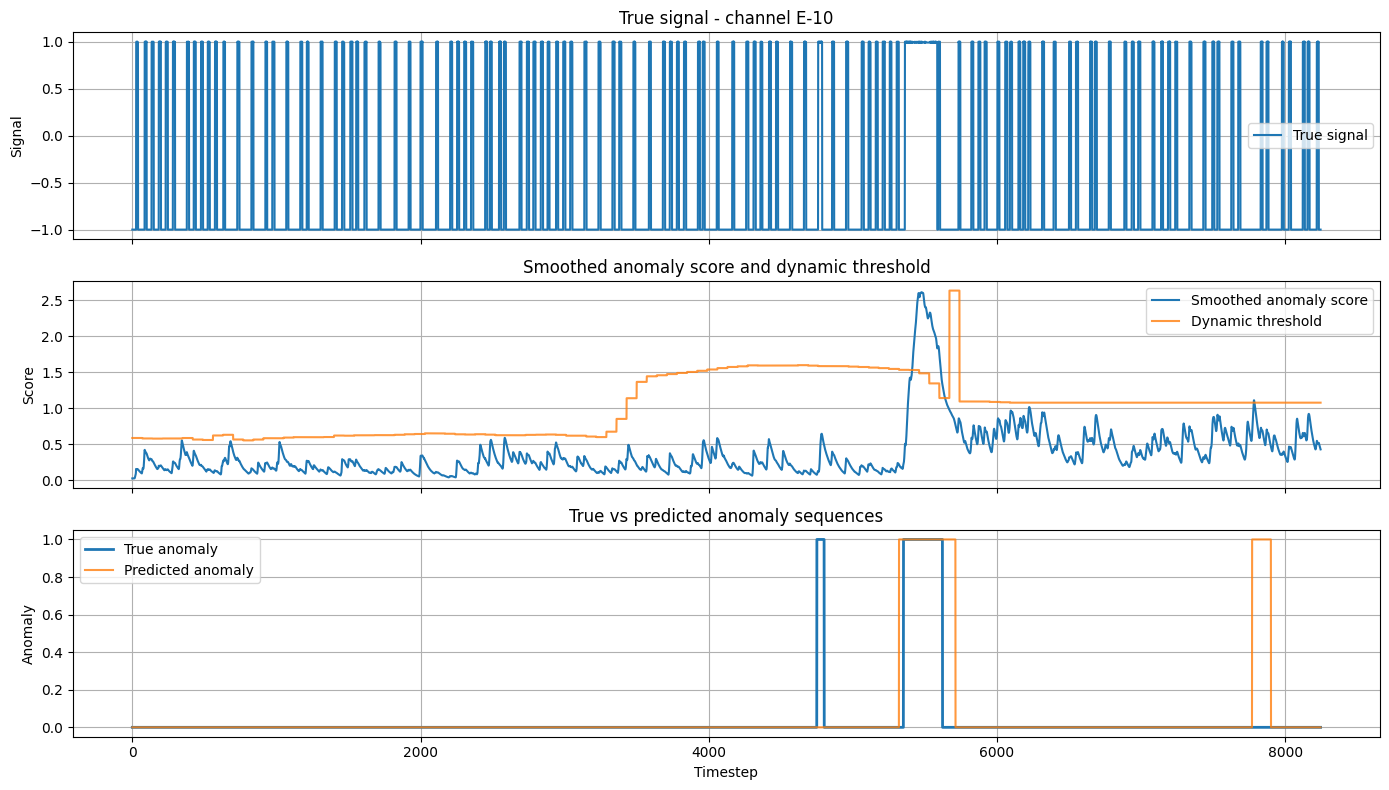

In [ ]:
plot_channel_diagnostics(
    ch="E-10",
    predictions=None,
    smoothed_errors=mlp_smoothed_scores,
    thresholds=mlp_thresholds,
    predictions_binary=mlp_predictions_binary,
    model_name="MLP"
)

By analyzing plots, we notice many interesting behaviours of our framework that should be better investigated. 

Around timestep 3500, we observe a sustained elevation in the dynamic threshold (the orange step-function). Notably, this increase does not strictly correlate with a massive spike in the anomaly score itself, but rather with an increase in the *variance* of the background noise. As the sliding window ingests this noisier regime, the standard deviation ($\sigma$) inflates. Multiplied by the optimized $z$-factor, this forces the threshold upward to defensively suppress potential False Positives (Alert Fatigue).

However, this defensive mechanism comes at a severe cost. Because the algorithm relies on a long historical sliding window, the threshold remains artificially elevated long after the noisy period has visually subsided. This creates a "blind spot" or hysteresis effect. 

When a true anomaly occurs later in the sequence (e.g., around timestep 4700-4800), the anomaly score rightfully registers a spike. Yet, because the threshold has not fully decayed from the previous high-variance event, the score fails to breach it. This results in a clear **False Negative**—a missed detection directly caused by the algorithm's lagging memory of past noise. 

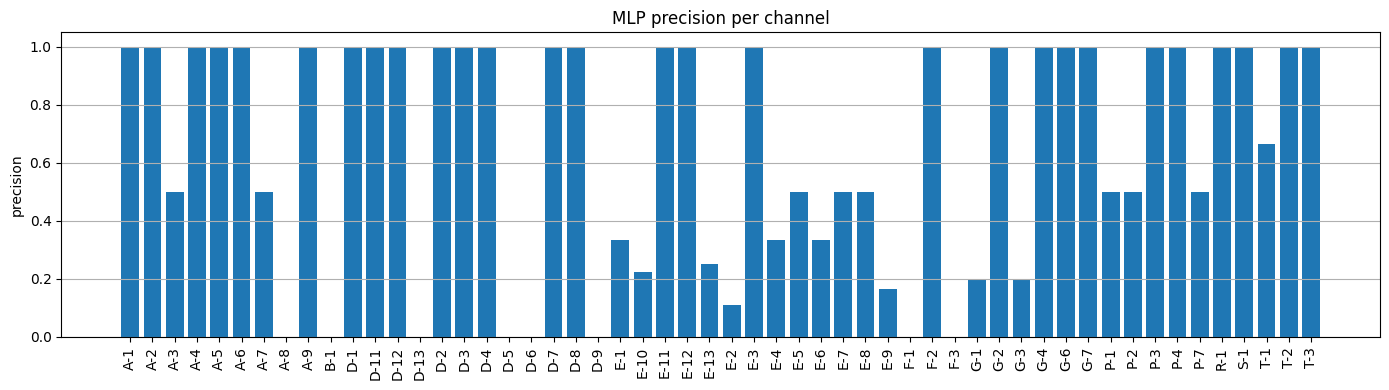

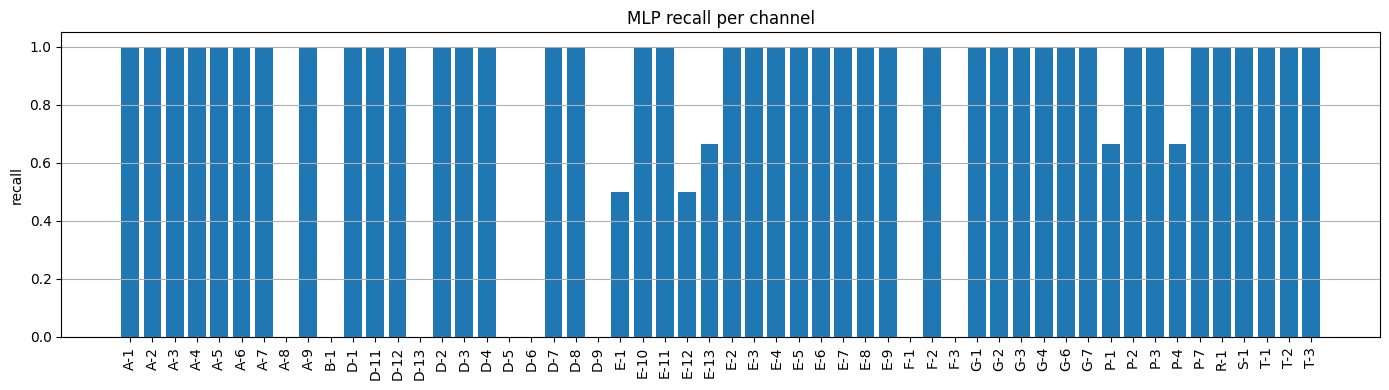

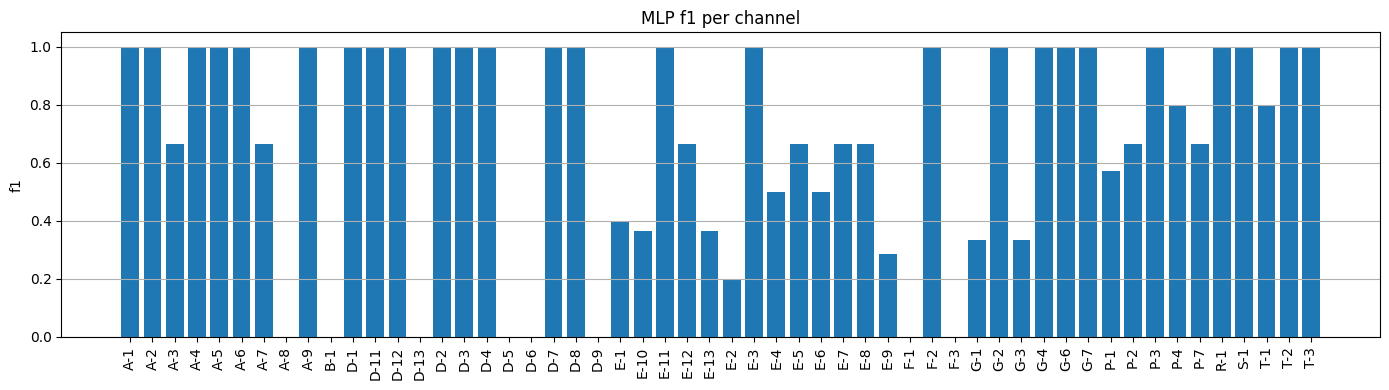

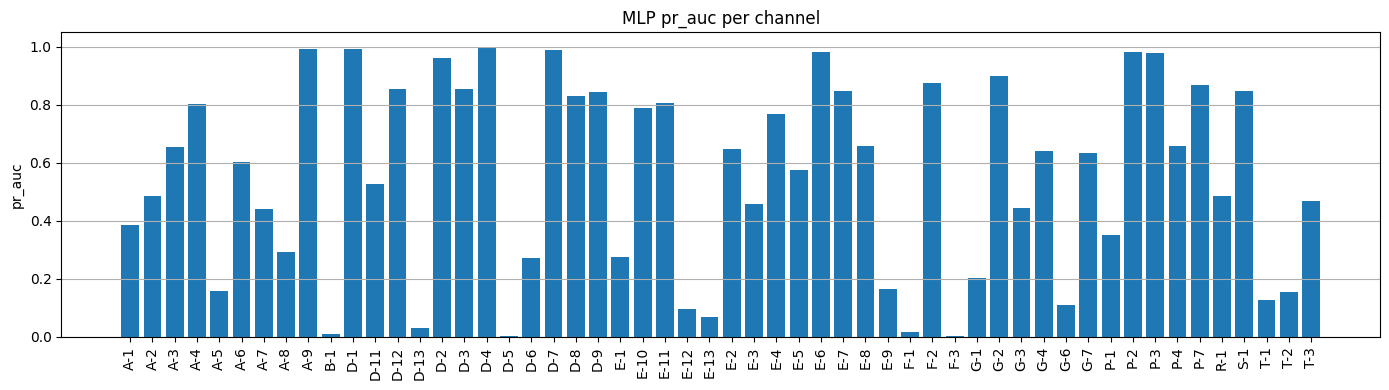

In [ ]:
plot_overall_metrics(mlp_results_df,method_name='MLP')

### Multi-Layer Perceptron Variational Autoencoder (MLP-VAE)

The VAE operates as a probabilistic extension of the standard deterministic Autoencoder. Instead of mapping each input window rigidly to a single latent vector, the encoder maps the flattened input to a latent probability distribution, defined mathematically as:

$$
q_\phi(z|x) = \mathcal{N}(\mu(x), \operatorname{diag}(\sigma^2(x)))
$$

A latent sample is then drawn using the reparameterization trick and passed to the decoder, which attempts to reconstruct the original input window. The model is optimized by minimizing a loss function composed of two distinct terms: a reconstruction error and a Kullback-Leibler (KL) divergence regularization term. The reconstruction term encourages high fidelity between the input and the output, while the KL divergence constrains the latent distribution, pushing it toward a standard normal prior:

$$
p(z) = \mathcal{N}(0, I)
$$

During inference, the anomaly score is derived directly from the VAE's reconstruction error. The underlying assumption is that windows generated by nominal telemetry behavior will be mapped to dense, well-learned regions of the latent space and reconstructed accurately, whereas anomalous windows will fall outside this manifold and produce significantly higher reconstruction errors.

In [ ]:
class VAEDataset(Dataset):
    def __init__(self, X):
        X = np.asarray(X)
        self.X = torch.tensor(X.reshape(X.shape[0], -1), dtype=torch.float32)      # Flattened 

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx]


def make_vae_loader(X, batch_size=64, shuffle=True):
    dataset = VAEDataset(X)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In this implementation, each telemetry window $X_i \in \mathbb{R}^{250 \times 25}$ is flattened into a vector of length 6250 before being passed to the VAE. The encoder first maps this vector to an intermediate representation and then produces two latent vectors: the mean $\mu$ and the log-variance $\log \sigma^2$. The use of `logvar` improves numerical stability and ensures that the variance is positive after exponentiation.

The latent vector is sampled through the reparameterization trick:

$$
z = \mu + \sigma \epsilon, \qquad \epsilon \sim \mathcal{N}(0, I)
$$

In the code, this operation is implemented by the `reparameterize` function. First, the standard deviation is recovered from the predicted log-variance:

$$
\sigma = \exp\left(\frac{1}{2}\log\sigma^2\right)
$$

Then, a random noise vector $\epsilon$ is sampled from a standard normal distribution with the same shape as $\sigma$. The latent vector is obtained as:

$$
z = \mu + \sigma \epsilon
$$

This avoids sampling directly from $\mathcal{N}(\mu, \sigma^2)$. Instead, the randomness is isolated in $\epsilon$, while $\mu$ and $\sigma$ remain differentiable outputs of the encoder. This is necessary to train the VAE with backpropagation.

The decoder then maps $z$ back to the original input dimension, producing a reconstructed version of the flattened telemetry window.

The training objective is:

$$
\mathcal{L}_{VAE}
=
\mathcal{L}_{recon}
+
\beta \mathcal{L}_{KL}
$$

where $\mathcal{L}_{recon}$ is the mean squared reconstruction error and $\mathcal{L}_{KL}$ penalizes deviations of the learned latent distribution from the standard normal prior. In this project, $\beta$ is kept small so that the model mainly focuses on reconstruction quality while still preserving a regularized latent space.

At inference time, the VAE anomaly score is computed at window level as the reconstruction error plus the weighted KL term. The resulting score sequence is then processed with the same EWMA smoothing, dynamic thresholding, buffering, inverse-error check, pruning, and sequence-based evaluation used for the LSTM pipeline. This makes the comparison fair at the detection stage, while keeping the modeling assumption different: reconstruction for the VAE, forecasting for the LSTM.

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_size, latent_size=16):
        super().__init__()

        self.input_size = input_size
        self.latent_size = latent_size

        self.encoder = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU()
        )

        self.mu_layer = nn.Linear(128, latent_size)
        self.logvar_layer = nn.Linear(128, latent_size)

        self.decoder = nn.Sequential(
            nn.Linear(latent_size, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, input_size)
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.mu_layer(h)
        logvar = self.logvar_layer(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z):
        x_recon = self.decoder(z)
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

#### VAE Loss and Anomaly Score

The VAE loss combines reconstruction quality and latent-space regularization:

$$
\mathcal{L}_{VAE}
=
\mathcal{L}_{recon}
+
\beta \mathcal{L}_{KL}
$$

where the reconstruction term is the MSE between the input window $x$ and its reconstruction $\hat{x}$:

$$
\mathcal{L}_{recon} = \text{MSE}(\hat{x}, x)
$$

and the KL term penalizes latent distributions that move too far from the standard normal prior $p(z)=\mathcal{N}(0,I)$:

$$
\mathcal{L}_{KL}
=
-\frac{1}{2}
\sum_j
\left(
1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2
\right)
$$

At inference time, the anomaly score is computed per window as reconstruction error plus the weighted KL term:

$$
s(x) = \text{reconstruction error} + \beta \cdot \text{KL error}
$$

A high score indicates that the window is difficult to reconstruct, has an irregular latent representation, or both. The resulting score sequence is then processed with the same EWMA smoothing, dynamic thresholding, buffering, pruning, and sequence-based evaluation.

In [ ]:
def vae_loss(x_recon, x, mu, logvar, beta=1.0):
    recon_loss = nn.functional.mse_loss(x_recon, x, reduction="mean")

    kl_loss = -0.5 * torch.mean(
        torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    )

    loss = recon_loss + beta * kl_loss

    return loss, recon_loss, kl_loss

def compute_vae_scores(model, X, batch_size=64, device="cpu"):
    dataset = VAEDataset(X)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    model.eval()
    scores = []

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device)
            x_recon, mu, logvar = model(X_batch)
            recon_error = torch.mean((x_recon - X_batch) ** 2, dim=1)
            kl_error = -0.5 * torch.sum(
                1 + logvar - mu.pow(2) - logvar.exp(),
                dim=1
            )

            score = recon_error + kl_error * 1e-3
            scores.append(score.cpu().numpy())

    return np.concatenate(scores)

In [ ]:
def train_vae_channel(
    X_train,
    latent_size=16,
    batch_size=64,
    epochs=35,
    lr=1e-3,
    beta=1e-3,
    device="cpu"
):
    train_loader = make_vae_loader(
        X_train,
        batch_size=batch_size,
        shuffle=True
    )

    input_size = X_train.shape[1] * X_train.shape[2]

    model = VAE(
        input_size=input_size,
        latent_size=latent_size
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []

    for epoch in range(epochs):
        model.train()

        total_loss = 0.0
        total_recon = 0.0
        total_kl = 0.0

        for X_batch in train_loader:
            X_batch = X_batch.to(device)

            x_recon, mu, logvar = model(X_batch)

            loss, recon_loss, kl_loss = vae_loss(
                x_recon=x_recon,
                x=X_batch,
                mu=mu,
                logvar=logvar,
                beta=beta
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * X_batch.size(0)
            total_recon += recon_loss.item() * X_batch.size(0)
            total_kl += kl_loss.item() * X_batch.size(0)

        total_loss /= len(train_loader.dataset)
        total_recon /= len(train_loader.dataset)
        total_kl /= len(train_loader.dataset)

        history.append({
            "loss": total_loss,
            "recon_loss": total_recon,
            "kl_loss": total_kl
        })

        print(
            f"Epoch {epoch+1:02d} | "
            f"loss: {total_loss:.6f} | "
            f"recon: {total_recon:.6f} | "
            f"kl: {total_kl:.6f}"
        )

    return model, history

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [ ]:
vae_models = {}
vae_histories = {}
vae_scores = {}
vae_smoothed_scores = {}
vae_predictions_binary = {}
vae_thresholds = {}
vae_metrics = {}

for ch in smap_channels_ids:
    print("=" * 80)
    print(f"Training VAE for channel {ch}")
    print("=" * 80)

    X_train = X_train_data[ch]
    X_test = X_test_data[ch]
    labels = labels_data[ch]

    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)
    print("labels:", labels.shape)

    model, history = train_vae_channel(
        X_train=X_train,
        latent_size=16,
        batch_size=64,
        epochs=35,
        lr=1e-3,
        beta=1e-3,
        device=device
    )

    scores = compute_vae_scores(
        model=model,
        X=X_test,
        batch_size=64,
        device=device
    )

    smoothed_scores = apply_ewma_smoothing(
        scores,
        batch_size=70,
        window_size=30,
        smoothing_perc=0.05
    )

    y_pred, thresholds, postprocess_info = apply_dynamic_thresholding(
        test_smoothed=smoothed_scores,
        batch_size=70,
        window_size=30,
        error_buffer=100,
        p=0.13,
        pruning=True,
        inverse=True
    )

    metrics = evaluate_sequences(
        y_true=labels,
        y_pred=y_pred,
        y_scores=smoothed_scores
    )

    vae_models[ch] = model
    vae_histories[ch] = history
    vae_scores[ch] = scores
    vae_smoothed_scores[ch] = smoothed_scores
    vae_predictions_binary[ch] = y_pred
    vae_thresholds[ch] = thresholds
    vae_metrics[ch] = metrics

    display(metrics)

Training VAE for channel A-1
X_train: (2621, 250, 25)
X_test: (8381, 250, 25)
labels: (8381,)
Epoch 01 | loss: 0.030439 | recon: 0.030279 | kl: 0.159967
Epoch 02 | loss: 0.021086 | recon: 0.021032 | kl: 0.053790
Epoch 03 | loss: 0.020435 | recon: 0.020402 | kl: 0.032701
Epoch 04 | loss: 0.020163 | recon: 0.020139 | kl: 0.023203
Epoch 05 | loss: 0.019974 | recon: 0.019956 | kl: 0.017161
Epoch 06 | loss: 0.019884 | recon: 0.019863 | kl: 0.021371
Epoch 07 | loss: 0.019808 | recon: 0.019729 | kl: 0.078536
Epoch 08 | loss: 0.019578 | recon: 0.019197 | kl: 0.381696
Epoch 09 | loss: 0.019475 | recon: 0.019028 | kl: 0.447653
Epoch 10 | loss: 0.019420 | recon: 0.018966 | kl: 0.453882
Epoch 11 | loss: 0.019365 | recon: 0.018871 | kl: 0.493915
Epoch 12 | loss: 0.019359 | recon: 0.018864 | kl: 0.495100
Epoch 13 | loss: 0.019324 | recon: 0.018769 | kl: 0.555303
Epoch 14 | loss: 0.019258 | recon: 0.018684 | kl: 0.574209
Epoch 15 | loss: 0.019201 | recon: 0.018548 | kl: 0.652693
Epoch 16 | loss: 0.01

,TP,FP,FN,precision,recall,f1,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.022507,0.0


Training VAE for channel A-2
X_train: (2389, 250, 25)
X_test: (7655, 250, 25)
labels: (7655,)
Epoch 01 | loss: 0.034930 | recon: 0.034834 | kl: 0.095399
Epoch 02 | loss: 0.033173 | recon: 0.032936 | kl: 0.237281
Epoch 03 | loss: 0.030342 | recon: 0.028804 | kl: 1.538721
Epoch 04 | loss: 0.026791 | recon: 0.023932 | kl: 2.859451
Epoch 05 | loss: 0.025344 | recon: 0.022007 | kl: 3.336495
Epoch 06 | loss: 0.024664 | recon: 0.021407 | kl: 3.256483
Epoch 07 | loss: 0.024232 | recon: 0.020994 | kl: 3.237621
Epoch 08 | loss: 0.023916 | recon: 0.020670 | kl: 3.246100
Epoch 09 | loss: 0.023567 | recon: 0.020419 | kl: 3.147743
Epoch 10 | loss: 0.023452 | recon: 0.020300 | kl: 3.152314
Epoch 11 | loss: 0.023273 | recon: 0.020192 | kl: 3.081375
Epoch 12 | loss: 0.023222 | recon: 0.020074 | kl: 3.147860
Epoch 13 | loss: 0.023120 | recon: 0.020043 | kl: 3.077246
Epoch 14 | loss: 0.022901 | recon: 0.019856 | kl: 3.044665
Epoch 15 | loss: 0.022910 | recon: 0.019777 | kl: 3.133353
Epoch 16 | loss: 0.02

,TP,FP,FN,precision,recall,f1,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.013214,0.0


Training VAE for channel A-3
X_train: (2477, 250, 25)
X_test: (7946, 250, 25)
labels: (7946,)
Epoch 01 | loss: 0.030349 | recon: 0.030274 | kl: 0.075586
Epoch 02 | loss: 0.028906 | recon: 0.028826 | kl: 0.080332
Epoch 03 | loss: 0.027615 | recon: 0.026772 | kl: 0.842261
Epoch 04 | loss: 0.027051 | recon: 0.026016 | kl: 1.035477
Epoch 05 | loss: 0.026613 | recon: 0.025460 | kl: 1.153055
Epoch 06 | loss: 0.026140 | recon: 0.024726 | kl: 1.413619
Epoch 07 | loss: 0.024578 | recon: 0.022463 | kl: 2.114410
Epoch 08 | loss: 0.023541 | recon: 0.021097 | kl: 2.443639
Epoch 09 | loss: 0.022908 | recon: 0.020324 | kl: 2.583906
Epoch 10 | loss: 0.022481 | recon: 0.019852 | kl: 2.628154
Epoch 11 | loss: 0.022131 | recon: 0.019561 | kl: 2.570227
Epoch 12 | loss: 0.022011 | recon: 0.019448 | kl: 2.563173
Epoch 13 | loss: 0.021964 | recon: 0.019375 | kl: 2.588511
Epoch 14 | loss: 0.021944 | recon: 0.019367 | kl: 2.576144
Epoch 15 | loss: 0.021848 | recon: 0.019260 | kl: 2.587939
Epoch 16 | loss: 0.02

...

,TP,FP,FN,precision,recall,f1,pr_auc,predicted_anomaly_ratio
0,0,1,2,0.0,0.0,0.0,0.110052,0.036035


Training VAE for channel T-2
X_train: (2596, 250, 25)
X_test: (8366, 250, 25)
labels: (8366,)
Epoch 01 | loss: 0.022426 | recon: 0.022329 | kl: 0.097447
Epoch 02 | loss: 0.018620 | recon: 0.018560 | kl: 0.059290
Epoch 03 | loss: 0.018072 | recon: 0.017765 | kl: 0.307027
Epoch 04 | loss: 0.014785 | recon: 0.012813 | kl: 1.972624
Epoch 05 | loss: 0.012751 | recon: 0.010097 | kl: 2.653913
Epoch 06 | loss: 0.011231 | recon: 0.008293 | kl: 2.937765
Epoch 07 | loss: 0.010602 | recon: 0.007634 | kl: 2.968361
Epoch 08 | loss: 0.010042 | recon: 0.006995 | kl: 3.046313
Epoch 09 | loss: 0.009570 | recon: 0.006538 | kl: 3.032780
Epoch 10 | loss: 0.009074 | recon: 0.006052 | kl: 3.021464
Epoch 11 | loss: 0.008693 | recon: 0.005732 | kl: 2.961249
Epoch 12 | loss: 0.008552 | recon: 0.005551 | kl: 3.001049
Epoch 13 | loss: 0.008473 | recon: 0.005492 | kl: 2.981059
Epoch 14 | loss: 0.008357 | recon: 0.005399 | kl: 2.957583
Epoch 15 | loss: 0.008255 | recon: 0.005270 | kl: 2.985024
Epoch 16 | loss: 0.00

,TP,FP,FN,precision,recall,f1,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.123099,0.0


Training VAE for channel T-3
X_train: (2617, 250, 25)
X_test: (8320, 250, 25)
labels: (8320,)
Epoch 01 | loss: 0.011933 | recon: 0.011828 | kl: 0.104495
Epoch 02 | loss: 0.003067 | recon: 0.003031 | kl: 0.036029
Epoch 03 | loss: 0.002536 | recon: 0.002511 | kl: 0.025410
Epoch 04 | loss: 0.002232 | recon: 0.002217 | kl: 0.015494
Epoch 05 | loss: 0.002062 | recon: 0.002053 | kl: 0.009048
Epoch 06 | loss: 0.001985 | recon: 0.001980 | kl: 0.004718
Epoch 07 | loss: 0.001937 | recon: 0.001935 | kl: 0.002490
Epoch 08 | loss: 0.001913 | recon: 0.001911 | kl: 0.001443
Epoch 09 | loss: 0.001890 | recon: 0.001889 | kl: 0.000943
Epoch 10 | loss: 0.001868 | recon: 0.001867 | kl: 0.000660
Epoch 11 | loss: 0.001857 | recon: 0.001856 | kl: 0.000495
Epoch 12 | loss: 0.001848 | recon: 0.001847 | kl: 0.000373
Epoch 13 | loss: 0.001839 | recon: 0.001839 | kl: 0.000298
Epoch 14 | loss: 0.001834 | recon: 0.001834 | kl: 0.000246
Epoch 15 | loss: 0.001831 | recon: 0.001831 | kl: 0.000197
Epoch 16 | loss: 0.00

,TP,FP,FN,precision,recall,f1,pr_auc,predicted_anomaly_ratio
0,1,0,1,1.0,0.5,0.666667,0.021174,0.063942


In [ ]:
vae_results_df,vae_summary_df = generate_results_view(vae_metrics)

,channel_id,TP,FP,FN,precision,recall,f1,pr_auc,predicted_anomaly_ratio
0,A-1,0,0,1,0.0,0.000000,0.000000,0.022507,0.000000
1,A-2,0,0,1,0.0,0.000000,0.000000,0.013214,0.000000
2,A-3,0,0,1,0.0,0.000000,0.000000,0.026797,0.000000
3,A-4,0,0,1,0.0,0.000000,0.000000,0.011363,0.000000
4,A-5,0,0,1,0.0,0.000000,0.000000,0.013221,0.000000
5,A-6,0,0,1,0.0,0.000000,0.000000,0.023937,0.000000
6,A-7,1,0,0,1.0,1.000000,1.000000,0.160030,0.066890
7,A-8,1,0,0,1.0,1.000000,1.000000,0.284606,0.043125
8,A-9,1,0,0,1.0,1.000000,1.000000,0.285769,0.051376
9,B-1,1,0,0,1.0,1.000000,1.000000,0.009512,0.071933


precision                  0.592593
recall                     0.567901
f1                         0.564815
pr_auc                     0.289983
predicted_anomaly_ratio    0.039918
dtype: float64

In [ ]:
save_results(vae_results_df,vae_summary_df,method_name='VAE')

### VAE Results Analysis

The VAE reconstruction-based pipeline obtains an average sequence-level precision of 0.593, recall of 0.568, and F1-score of 0.565 across the SMAP channels. The predicted anomaly ratio is approximately 3.99%, meaning that the model marks only a small fraction of the test windows as anomalous. This indicates a selective behavior: the detector does not over-flag the test set, but it also misses a relevant number of labeled anomaly sequences.

The per-channel results show a strongly heterogeneous behavior. Several channels are detected perfectly at sequence level, with precision, recall, and F1-score equal to 1.0. This means that, for those channels, the reconstruction-based score was sufficient to isolate the labeled anomaly interval without generating false positive sequences.

However, many channels have zero recall and zero F1-score. In most of these cases, the predicted anomaly ratio is also zero, meaning that the dynamic thresholding stage did not produce any final anomaly sequence. This suggests that, on these channels, the reconstruction score did not exceed the adaptive threshold strongly enough, even when labeled anomalies were present.

The model also shows some intermediate cases. Channels such as E-1, E-2, E-4, and E-6 detect the true anomaly but also produce one false positive sequence, resulting in precision equal to 0.5. Other channels, such as E-10, E-11, G-7, P-4, and T-3, have high precision but reduced recall, meaning that the detector raises few false alarms but misses part of the labeled anomalous intervals.

The average PR-AUC is 0.290, which is relatively low. This indicates that the continuous VAE anomaly scores do not consistently rank anomalous windows above nominal windows across all channels. Some channels show high PR-AUC but zero final recall, such as D-1 and D-2. This means that the score ranking may contain useful information, but the final dynamic thresholding and post-processing stage can still be too conservative for those channels.

Overall, the VAE provides a meaningful reconstruction-based baseline, but its behavior is highly channel-dependent. The low predicted anomaly ratio and the many zero-recall channels suggest that the current VAE configuration tends to be conservative: it avoids many false positives, but often fails to trigger on labeled anomaly sequences. Further improvements could involve tuning the latent dimension, the KL weight, or the thresholding parameters specifically for reconstruction-based scores.

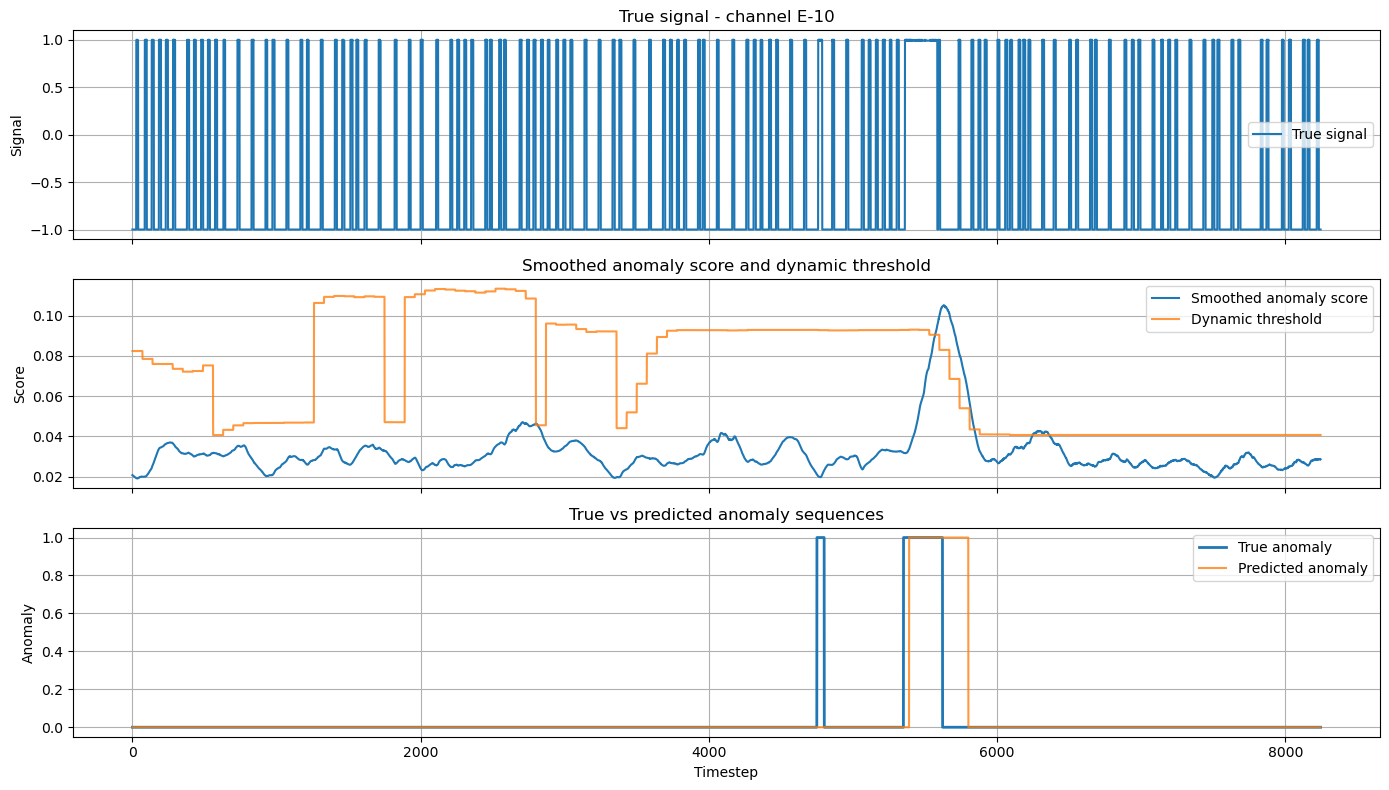

In [ ]:
plot_channel_diagnostics(
    ch="E-10",
    predictions=None,
    smoothed_errors=vae_smoothed_scores,
    thresholds=vae_thresholds,
    predictions_binary=vae_predictions_binary,
    model_name="VAE"
)

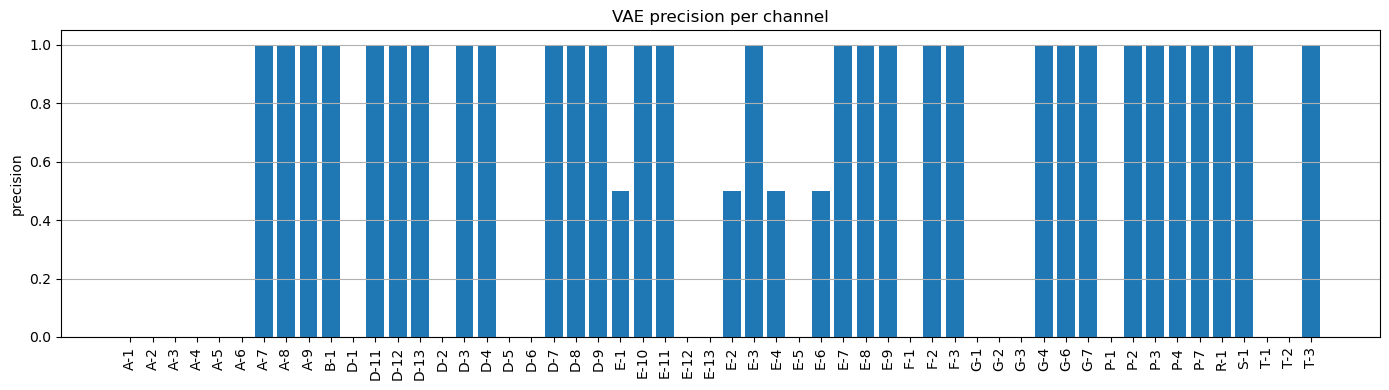

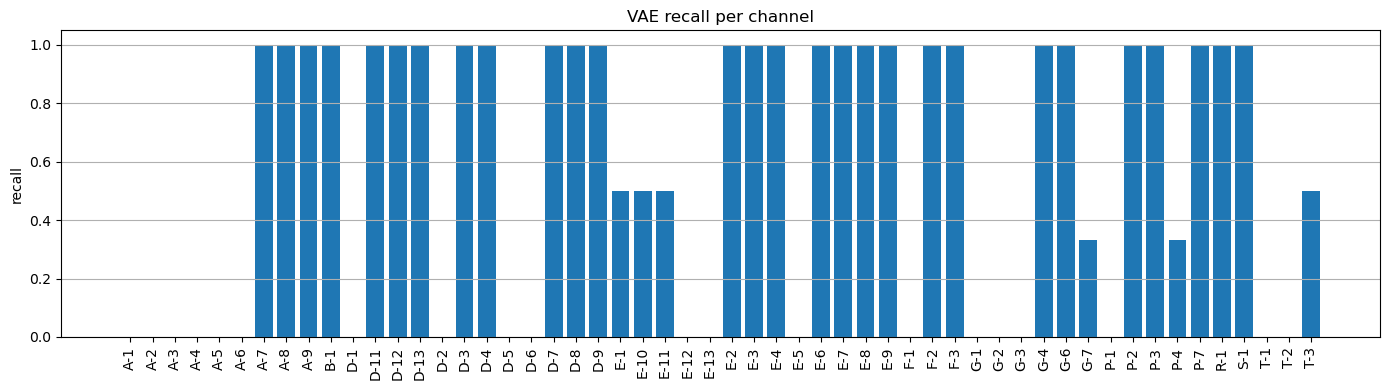

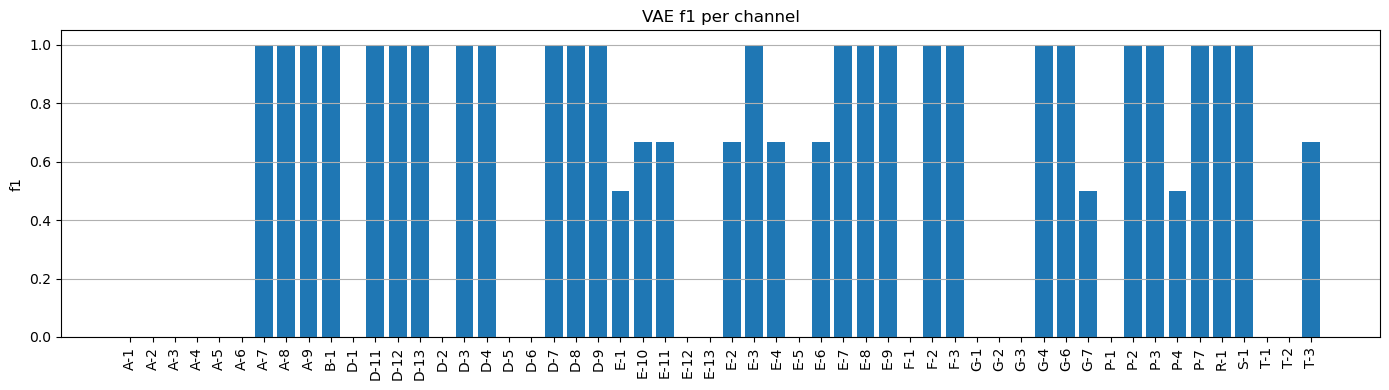

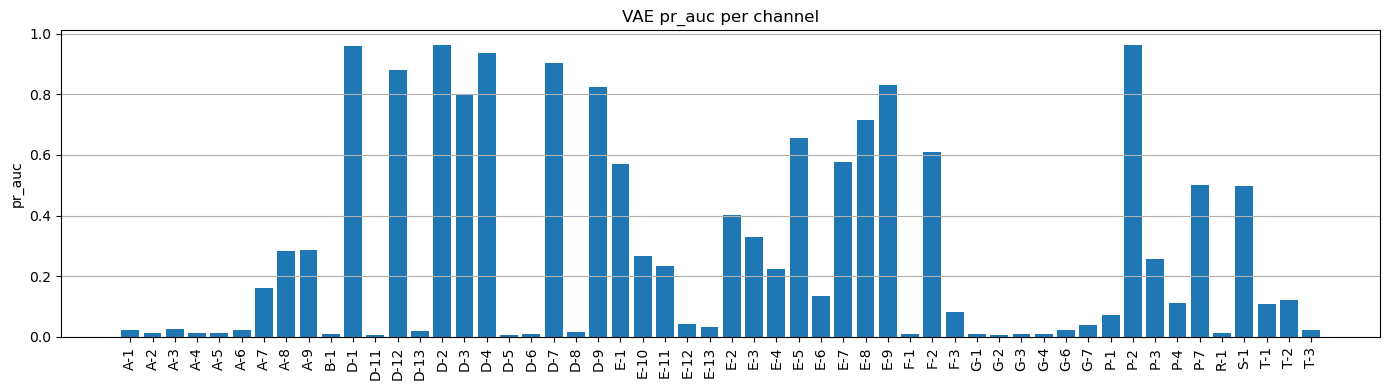

In [ ]:
plot_overall_metrics(vae_results_df,method_name='VAE')

## DNN MODELS

The anomaly detection problem is formulated as a forecasting task. Instead of training a model to directly classify each timestep as normal or anomalous, the model is trained to predict the expected future behavior of the main telemetry signal from its recent history and from the associated command variables. The underlying assumption is that, during nominal operation, the future evolution of the signal should be predictable from the previous temporal context. An anomaly is then identified when the observed value deviates significantly from the predicted one.

This formulation is suitable for semi-supervised anomaly detection because the model can be trained only on normal telemetry data, without requiring anomalous examples during training. The anomaly labels are used only for final evaluation. This is particularly relevant for spacecraft telemetry, where failures and anomalous events are rare, heterogeneous, and difficult to model explicitly.

Deep learning models are used because the relationship between telemetry signals and command variables can be nonlinear and temporally dependent. A simple model may fail to capture delayed effects, temporal dependencies, or changes in the signal caused by different command configurations. Sequence models are therefore more appropriate, since they can exploit the ordered structure of the data.

In this project, two forecasting-based neural architectures are considered. The LSTM model is used as a recurrent baseline designed to capture temporal dependencies through hidden states. The Transformer model is used as a more flexible sequence model based on attention mechanisms, allowing the model to weigh different parts of the input window when producing the forecast.

Both models receive as input a sliding window of past multivariate observations and output the next future values of the main telemetry signal. The anomaly score is then computed from the forecasting error. This keeps the detection strategy model-independent: different forecasting models can be compared while using the same downstream anomaly scoring, smoothing, dynamic thresholding, and sequence-based evaluation procedure.

### LSTM Forecasting Architecture

The first deep learning model used in this project is an LSTM-based forecasting model. The input of the network is a sliding window of past multivariate telemetry observations with shape:

$$
X_i \in \mathbb{R}^{250 \times 25}
$$

where 250 is the length of the temporal context and 25 is the number of available features for each SMAP channel. The first feature corresponds to the main telemetry signal, while the remaining features provide command-related contextual information.

The model follows a Telemanom-style architecture based on stacked recurrent layers. The input sequence is processed by a two-layer LSTM with 80 hidden units. The LSTM reads the temporal window step by step and compresses the information contained in the past trajectory into a hidden representation. Dropout is applied as regularization in order to reduce overfitting, especially because each channel is trained independently and some channels have relatively short training sequences.

Only the final hidden representation is passed to a fully connected output layer. The output layer produces a vector of 10 future predictions:

$$
\hat{y}_i \in \mathbb{R}^{10}
$$

corresponding to the next 10 expected values of the main telemetry signal:

$$
\hat{y}_i =
[\hat{x}_{i+250,0}, \hat{x}_{i+251,0}, \ldots, \hat{x}_{i+259,0}]
$$

The model is trained using mean squared error between the predicted and observed future telemetry values. Therefore, the LSTM is not trained to classify anomalies directly. It learns the nominal temporal dynamics of the signal, conditioned on the recent telemetry history and command context. Anomalies are detected only after forecasting, by comparing the predicted signal with the observed one and applying the dynamic thresholding pipeline to the resulting prediction errors.

#### LSTM Forecasting Pipeline

The LSTM model is only the forecasting component of the anomaly detection pipeline. The complete procedure is composed of several sequential steps.

First, for each SMAP channel, the model receives a sliding window of past multivariate telemetry observations and predicts the next 10 future values of the main telemetry signal. This produces a multi-step forecast for each input window.

Since consecutive windows overlap, the same future timestep can be predicted multiple times by different windows. Therefore, the multi-step predictions are aggregated into a single predicted signal within diagonal aggregation strategy. This gives one forecasted value for each evaluated timestep.

The aggregated prediction is then compared with the observed telemetry value. The anomaly score is computed as the absolute forecasting error:

$$
e_t = |\hat{x}_{t,0} - x_{t,0}|
$$

The raw error signal is smoothed using EWMA in order to reduce the effect of isolated noisy peaks and obtain a more stable anomaly score.

The smoothed errors are then processed with dynamic non-parametric thresholding.

After thresholding, post-processing is applied. The detected anomaly candidates are expanded with a temporal error buffer, inverted errors are also checked to capture unusual deviations in the opposite direction, and pruning is used to remove weak anomaly sequences that are not sufficiently separated from the nominal error distribution.

The final binary anomaly predictions are then evaluated using sequence-based metrics, where contiguous anomalous intervals are compared against the labeled anomaly sequences.

In [ ]:
class ForecastDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loader(X, y, batch_size=64, shuffle=True):
    dataset = ForecastDataset(X, y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In [ ]:
class LSTMForecaster(nn.Module):
    def __init__(
        self,
        input_size=25,
        hidden_size=80,
        num_layers=2,
        dropout=0.3,
        n_predictions=10
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, n_predictions)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        last_hidden = self.dropout(last_hidden)
        y_hat = self.fc(last_hidden)
        return y_hat

In [ ]:
def train_lstm_channel(
    X_train,
    y_train,
    input_size=25,
    hidden_size=80,
    num_layers=2,
    dropout=0.3,
    n_predictions=10,
    batch_size=64,
    epochs=35,
    lr=1e-3,
    device="cpu"
):
    train_loader = make_loader(
        X_train,
        y_train,
        batch_size=batch_size,
        shuffle=True
    )

    model = LSTMForecaster(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        n_predictions=n_predictions
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)
            loss = criterion(pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)
        history.append(train_loss)

        print(f"Epoch {epoch + 1:02d} | train loss: {train_loss:.6f}")

    return model, history

def predict_lstm_channel(model, X_test, batch_size=64, device="cpu"):
    test_tensor = torch.tensor(X_test, dtype=torch.float32)
    test_loader = DataLoader(test_tensor, batch_size=batch_size, shuffle=False)

    model.eval()
    preds = []

    with torch.no_grad():
        for X_batch in test_loader:
            X_batch = X_batch.to(device)
            pred = model(X_batch)
            preds.append(pred.cpu().numpy())

    return np.vstack(preds)

### Training and Detection Strategy Across SMAP Channels

The LSTM model is trained independently for each SMAP channel. This choice is motivated by the structure of the dataset: each channel represents a different telemetry stream, with its own signal dynamics, command context, training length, and anomaly patterns. A single global model would implicitly assume that all channels share the same temporal behavior, which is not necessarily true. Training one model per channel allows the forecasting model to specialize on the nominal dynamics of that specific telemetry signal.

For each channel, the LSTM is trained to predict the next 10 values of the main telemetry signal from the previous 250 multivariate observations. After prediction, the overlapping multi-step forecasts are aggregated into a single predicted signal, which is compared with the observed telemetry value to obtain the forecasting error.

The global results should be interpreted with caution. Averaged metrics across all channels provide a compact view of the overall behavior, but they do not tell the whole story. Some channels may be easier to forecast and detect, while others may have shorter training sequences, weaker signal structure, more constant features, or more difficult anomaly patterns. For this reason, both global metrics and per-channel metrics should be inspected.

Precision, recall, and F1-score summarize sequence-level detection performance after post-processing. PR-AUC provides an additional threshold-independent diagnostic based on the continuous anomaly scores before final binary decisions. The predicted anomaly ratio is used as a sanity check: very low values may indicate that the pipeline is missing most anomalies, while very high values may indicate excessive false alarms. The goal of this stage is to evaluate the complete LSTM-based detection pipeline before comparing it with alternative forecasting models such as Transformers.

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [ ]:
lstm_models = {}
lstm_histories = {}
lstm_predictions_multi = {}
lstm_predictions = {}
lstm_errors = {}
lstm_smoothed_errors = {}
lstm_predictions_binary = {}
lstm_thresholds = {}
lstm_metrics = {}

for ch in smap_channels_ids:
    print("=" * 80)
    print(f"Training LSTM for channel {ch}")
    print("=" * 80)

    X_train = X_train_data[ch]
    y_train = y_train_data[ch]

    X_test = X_test_data[ch]
    y_test = y_test_data[ch]
    labels = labels_data[ch]

    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print("labels:", labels.shape)

    model, history = train_lstm_channel(
        X_train=X_train,
        y_train=y_train,
        input_size=X_train.shape[2],
        hidden_size=80,
        num_layers=2,
        dropout=0.3,
        n_predictions=10,
        batch_size=64,
        epochs=35,
        lr=1e-3,
        device=device
    )

    y_hat_multi = predict_lstm_channel(
        model=model,
        X_test=X_test,
        batch_size=64,
        device=device
    )

    y_hat = aggregate_predictions(
        y_hat_multi,
        method="first"
    )

    y_true_signal = y_test[:, 0]

    errors = np.abs(y_hat - y_true_signal)

    smoothed_errors = apply_ewma_smoothing(
        errors,
        batch_size=70,
        window_size=30,
        smoothing_perc=0.05
    )

    y_pred, thresholds, postprocess_info = apply_dynamic_thresholding(
        test_smoothed=smoothed_errors,
        batch_size=70,
        window_size=30,
        error_buffer=100,
        p=0.13,
        pruning=True,
        inverse=True
    )

    metrics = evaluate_sequences(
        y_true=labels,
        y_pred=y_pred,
        y_scores=smoothed_errors
    )

    lstm_models[ch] = model
    lstm_histories[ch] = history
    lstm_predictions_multi[ch] = y_hat_multi
    lstm_predictions[ch] = y_hat
    lstm_errors[ch] = errors
    lstm_smoothed_errors[ch] = smoothed_errors
    lstm_predictions_binary[ch] = y_pred
    lstm_thresholds[ch] = thresholds
    lstm_metrics[ch] = metrics

    display(metrics)

Training LSTM for channel A-1
X_train: (2621, 250, 25)
y_train: (2621, 10)
X_test: (8381, 250, 25)
y_test: (8381, 10)
labels: (8381,)
Epoch 01 | train loss: 0.244362
Epoch 02 | train loss: 0.026942
Epoch 03 | train loss: 0.020649
Epoch 04 | train loss: 0.016862
Epoch 05 | train loss: 0.014285
Epoch 06 | train loss: 0.012109
Epoch 07 | train loss: 0.011200
Epoch 08 | train loss: 0.010239
Epoch 09 | train loss: 0.009330
Epoch 10 | train loss: 0.008728
Epoch 11 | train loss: 0.008126
Epoch 12 | train loss: 0.007581
Epoch 13 | train loss: 0.007056
Epoch 14 | train loss: 0.007076
Epoch 15 | train loss: 0.006995
Epoch 16 | train loss: 0.006742
Epoch 17 | train loss: 0.006161
Epoch 18 | train loss: 0.006089
Epoch 19 | train loss: 0.005943
Epoch 20 | train loss: 0.005927
Epoch 21 | train loss: 0.005793
Epoch 22 | train loss: 0.005431
Epoch 23 | train loss: 0.005319
Epoch 24 | train loss: 0.005349
Epoch 25 | train loss: 0.005297
Epoch 26 | train loss: 0.004959
Epoch 27 | train loss: 0.005002
Ep

,TP,FP,FN,precision,recall,f1,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,0.3043,0.030187


Training LSTM for channel A-2
X_train: (2389, 250, 25)
y_train: (2389, 10)
X_test: (7655, 250, 25)
y_test: (7655, 10)
labels: (7655,)
Epoch 01 | train loss: 0.212348
Epoch 02 | train loss: 0.081860
Epoch 03 | train loss: 0.051866
Epoch 04 | train loss: 0.045702
Epoch 05 | train loss: 0.043120
Epoch 06 | train loss: 0.039829
Epoch 07 | train loss: 0.038161
Epoch 08 | train loss: 0.037799
Epoch 09 | train loss: 0.035478
Epoch 10 | train loss: 0.035143
Epoch 11 | train loss: 0.034086
Epoch 12 | train loss: 0.032608
Epoch 13 | train loss: 0.033237
Epoch 14 | train loss: 0.032264
Epoch 15 | train loss: 0.032101
Epoch 16 | train loss: 0.030825
Epoch 17 | train loss: 0.031008
Epoch 18 | train loss: 0.032720
Epoch 19 | train loss: 0.030370
Epoch 20 | train loss: 0.030327
Epoch 21 | train loss: 0.030713
Epoch 22 | train loss: 0.029026
Epoch 23 | train loss: 0.028992
Epoch 24 | train loss: 0.028905
Epoch 25 | train loss: 0.028784
Epoch 26 | train loss: 0.029286
Epoch 27 | train loss: 0.028791
Ep

,TP,FP,FN,precision,recall,f1,pr_auc,predicted_anomaly_ratio
0,1,2,0,0.333333,1.0,0.5,0.521429,0.090007


Training LSTM for channel A-3
X_train: (2477, 250, 25)
y_train: (2477, 10)
X_test: (7946, 250, 25)
y_test: (7946, 10)
labels: (7946,)
Epoch 01 | train loss: 0.137666
Epoch 02 | train loss: 0.044467
Epoch 03 | train loss: 0.030582
Epoch 04 | train loss: 0.028524
Epoch 05 | train loss: 0.026986
Epoch 06 | train loss: 0.027487
Epoch 07 | train loss: 0.025865
Epoch 08 | train loss: 0.025454
Epoch 09 | train loss: 0.024287
Epoch 10 | train loss: 0.024066
Epoch 11 | train loss: 0.023887
Epoch 12 | train loss: 0.023380
Epoch 13 | train loss: 0.022888
Epoch 14 | train loss: 0.023205
Epoch 15 | train loss: 0.022251
Epoch 16 | train loss: 0.022215
Epoch 17 | train loss: 0.021512
Epoch 18 | train loss: 0.021095
Epoch 19 | train loss: 0.020910
Epoch 20 | train loss: 0.020700
Epoch 21 | train loss: 0.021224
Epoch 22 | train loss: 0.020840
Epoch 23 | train loss: 0.020949
Epoch 24 | train loss: 0.020347
Epoch 25 | train loss: 0.020311
Epoch 26 | train loss: 0.020148
Epoch 27 | train loss: 0.019653
Ep

...

,TP,FP,FN,precision,recall,f1,pr_auc,predicted_anomaly_ratio
0,1,2,1,0.333333,0.5,0.4,0.09986,0.050042


Training LSTM for channel T-2
X_train: (2596, 250, 25)
y_train: (2596, 10)
X_test: (8366, 250, 25)
y_test: (8366, 10)
labels: (8366,)
Epoch 01 | train loss: 0.366608
Epoch 02 | train loss: 0.192177
Epoch 03 | train loss: 0.117538
Epoch 04 | train loss: 0.081315
Epoch 05 | train loss: 0.089491
Epoch 06 | train loss: 0.076184
Epoch 07 | train loss: 0.070189
Epoch 08 | train loss: 0.073126
Epoch 09 | train loss: 0.059739
Epoch 10 | train loss: 0.058616
Epoch 11 | train loss: 0.037032
Epoch 12 | train loss: 0.034348
Epoch 13 | train loss: 0.037455
Epoch 14 | train loss: 0.033897
Epoch 15 | train loss: 0.026903
Epoch 16 | train loss: 0.032947
Epoch 17 | train loss: 0.025819
Epoch 18 | train loss: 0.028692
Epoch 19 | train loss: 0.018750
Epoch 20 | train loss: 0.032088
Epoch 21 | train loss: 0.028625
Epoch 22 | train loss: 0.017540
Epoch 23 | train loss: 0.017872
Epoch 24 | train loss: 0.017452
Epoch 25 | train loss: 0.019950
Epoch 26 | train loss: 0.030655
Epoch 27 | train loss: 0.023192
Ep

,TP,FP,FN,precision,recall,f1,pr_auc,predicted_anomaly_ratio
0,1,1,0,0.5,1.0,0.666667,0.122068,0.036338


Training LSTM for channel T-3
X_train: (2617, 250, 25)
y_train: (2617, 10)
X_test: (8320, 250, 25)
y_test: (8320, 10)
labels: (8320,)
Epoch 01 | train loss: 0.234036
Epoch 02 | train loss: 0.028363
Epoch 03 | train loss: 0.020663
Epoch 04 | train loss: 0.017418
Epoch 05 | train loss: 0.014959
Epoch 06 | train loss: 0.012800
Epoch 07 | train loss: 0.011225
Epoch 08 | train loss: 0.010719
Epoch 09 | train loss: 0.009356
Epoch 10 | train loss: 0.009131
Epoch 11 | train loss: 0.008165
Epoch 12 | train loss: 0.007880
Epoch 13 | train loss: 0.007712
Epoch 14 | train loss: 0.007120
Epoch 15 | train loss: 0.006834
Epoch 16 | train loss: 0.006652
Epoch 17 | train loss: 0.006645
Epoch 18 | train loss: 0.006118
Epoch 19 | train loss: 0.006194
Epoch 20 | train loss: 0.005758
Epoch 21 | train loss: 0.005725
Epoch 22 | train loss: 0.005480
Epoch 23 | train loss: 0.005409
Epoch 24 | train loss: 0.005309
Epoch 25 | train loss: 0.005236
Epoch 26 | train loss: 0.005219
Epoch 27 | train loss: 0.005066
Ep

,TP,FP,FN,precision,recall,f1,pr_auc,predicted_anomaly_ratio
0,2,0,0,1.0,1.0,1.0,0.396369,0.053606


In [ ]:
lstm_result_df,lstm_summary_df = generate_results_view(lstm_metrics)

,channel_id,TP,FP,FN,precision,recall,f1,pr_auc,predicted_anomaly_ratio
0,A-1,1,0,0,1.000000,1.000000,1.000000,0.304300,0.030187
1,A-2,1,2,0,0.333333,1.000000,0.500000,0.521429,0.090007
2,A-3,1,2,0,0.333333,1.000000,0.500000,0.437181,0.105336
3,A-4,1,0,0,1.000000,1.000000,1.000000,0.423041,0.037719
4,A-5,0,0,1,0.000000,0.000000,0.000000,0.012264,0.000000
5,A-6,1,0,0,1.000000,1.000000,1.000000,0.214715,0.063424
6,A-7,1,3,0,0.250000,1.000000,0.400000,0.886132,0.112160
7,A-8,1,0,0,1.000000,1.000000,1.000000,0.295833,0.181124
8,A-9,0,0,1,0.000000,0.000000,0.000000,0.927947,0.000000
9,B-1,0,0,1,0.000000,0.000000,0.000000,0.009929,0.000000


precision                  0.583113
recall                     0.734568
f1                         0.624691
pr_auc                     0.488805
predicted_anomaly_ratio    0.056340
dtype: float64

### LSTM Results Discussion

The LSTM-based forecasting pipeline obtains an average sequence-level precision of 0.583, recall of 0.735, and F1-score of 0.625 across the SMAP channels. These results indicate that the model is able to detect a large fraction of the labeled anomalous sequences, while still producing a moderate number of false alarm sequences. The recall value is higher than precision, meaning that the detector is more effective at capturing true anomalous intervals than at avoiding false positives.

The average F1-score of 0.625 suggests a reasonable balance between detection capability and false alarm control. Since the evaluation is sequence-based, this score should be interpreted at the anomaly-event level rather than at the single-timestep level. The predicted anomaly ratio is approximately 5.63%, meaning that the final pipeline marks only a limited portion of the evaluated timesteps as anomalous. This suggests that the detector is not degenerate: it is not classifying most of the test set as anomalous. At the same time, the precision value indicates that some predicted anomaly sequences still do not overlap with labeled anomalies.

The per-channel results show heterogeneous behavior across SMAP telemetry streams. Several channels reach perfect sequence-level precision, recall, and F1-score, meaning that all labeled anomaly sequences are detected without producing additional false alarm sequences. However, the model also fails completely on some channels, where precision, recall, and F1-score are equal to zero. In these cases, the detector either does not trigger any anomaly or triggers only false positives without overlapping the true labeled anomalous intervals.

This confirms that the average performance is driven by a mixture of successful and difficult channels. Some telemetry streams are easier to forecast and detect, while others likely have weaker anomaly-score separation, more complex dynamics, shorter useful training history, or anomaly patterns that are not well captured by the LSTM forecasting error. Channels with high recall but low precision indicate that the model detects the true anomalous sequences, but also generates additional false positive sequences.

The PR-AUC is 0.489 and varies substantially across channels. This metric should be interpreted separately from the sequence-level metrics, because PR-AUC evaluates the ranking quality of the continuous anomaly scores before the final binary decision, while precision, recall, and F1-score are computed after dynamic thresholding and post-processing. A moderate PR-AUC combined with stronger sequence-level recall means that the final thresholding strategy can still identify many labeled anomaly intervals, even if the continuous scores are not always globally well ranked.

Overall, the LSTM model provides a solid forecasting-based anomaly detection baseline. The results are stronger on recall than on precision and are clearly channel-dependent. Further improvements should focus on reducing false positives and improving the ranking quality of the anomaly scores, especially on channels where the current pipeline either misses the anomaly completely or produces excessive predicted anomaly sequences.

In [ ]:
save_results(lstm_result_df,lstm_summary_df,method_name='LSTM')

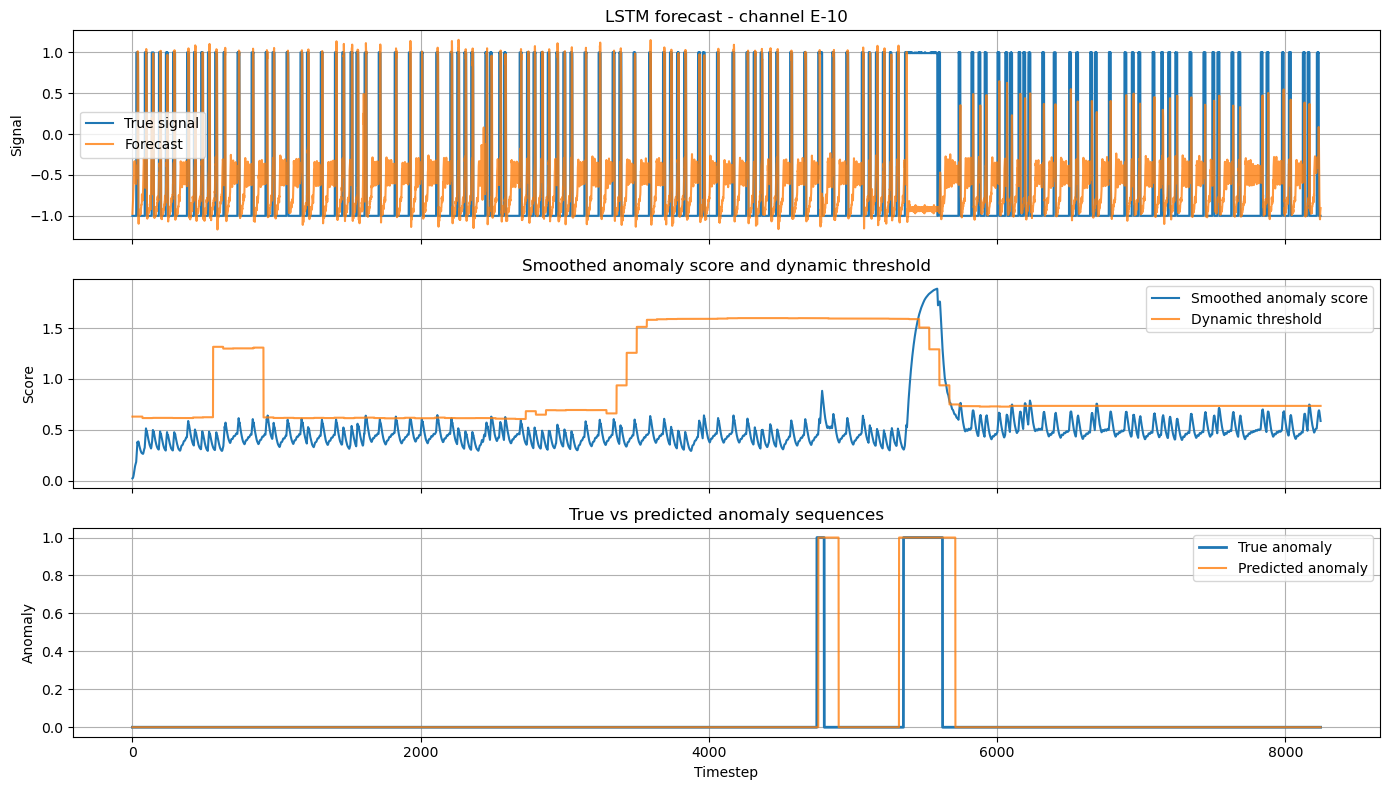

In [ ]:
plot_channel_diagnostics(
    ch="E-10",
    predictions=lstm_predictions,
    smoothed_errors=lstm_smoothed_errors,
    thresholds=lstm_thresholds,
    predictions_binary=lstm_predictions_binary,
    model_name="LSTM"
)

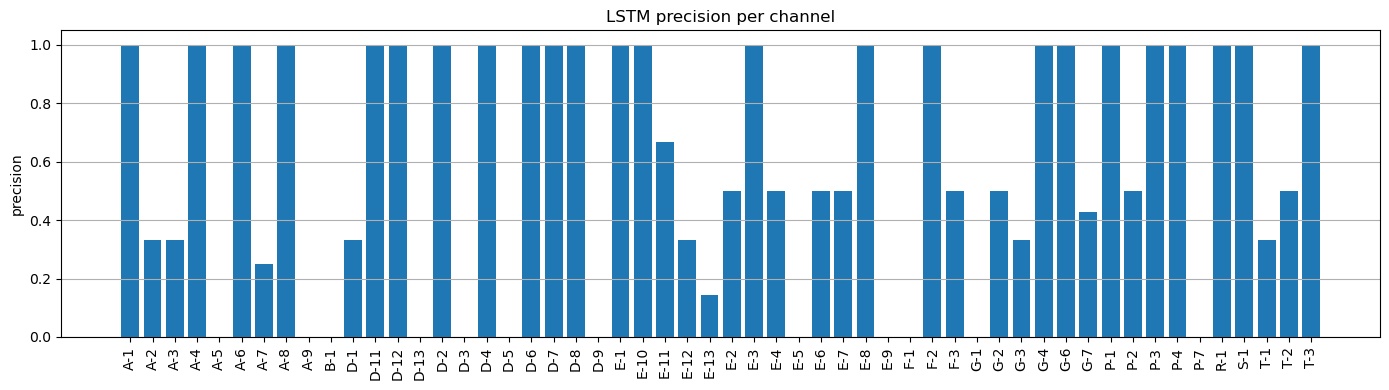

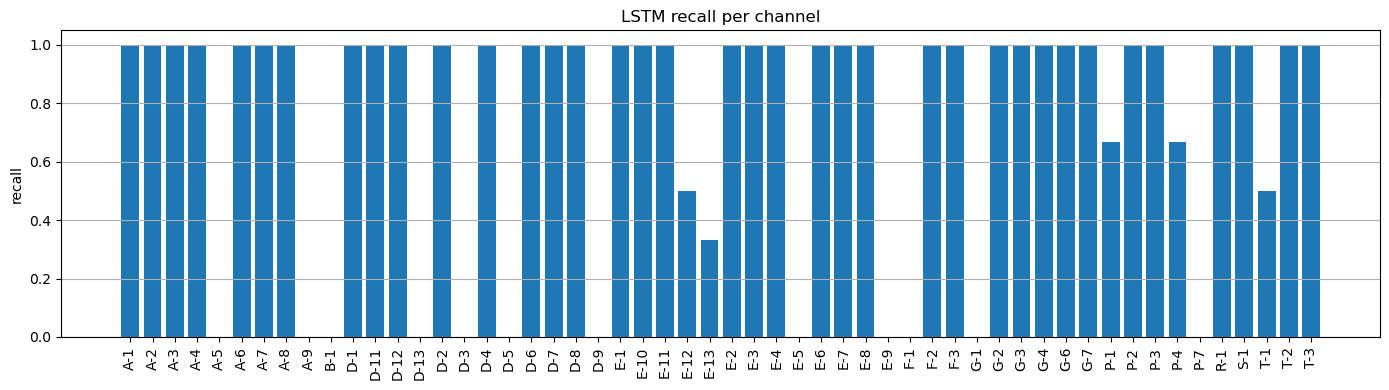

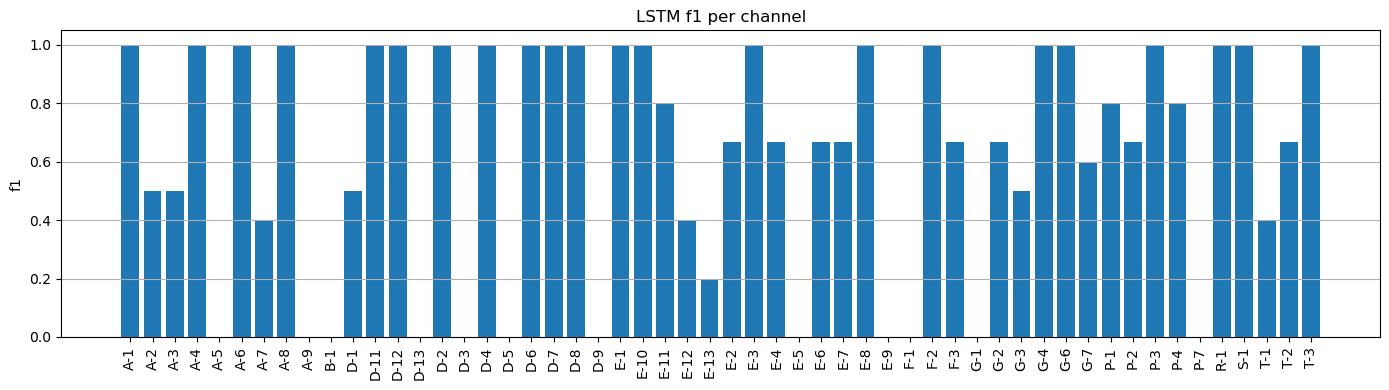

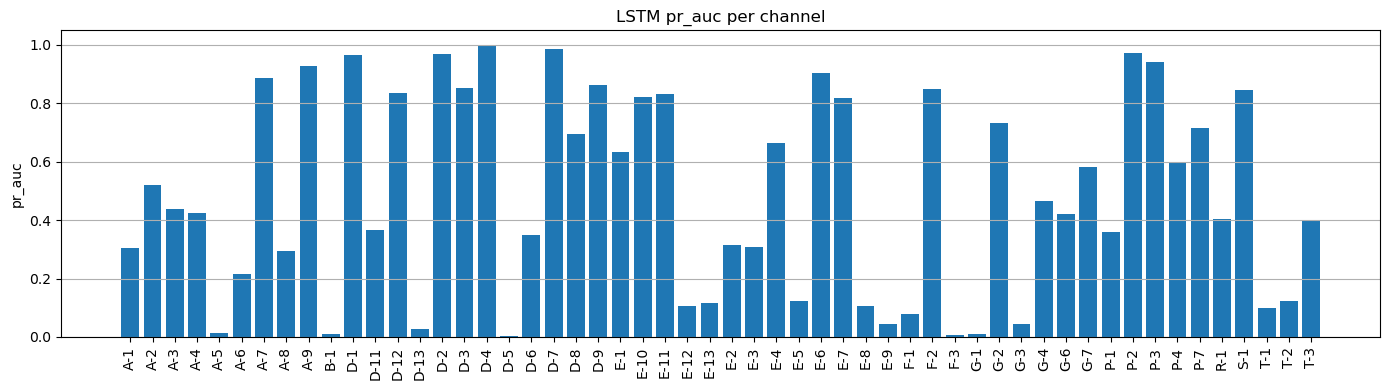

In [ ]:
plot_overall_metrics(lstm_result_df,method_name='LSTM')

### Reconstruction-Based vs Forecasting-Based Anomaly Scores

The VAE and the LSTM produce anomaly scores with different meanings. In the VAE pipeline, the anomaly score is based on the reconstruction error of the current telemetry window. The model receives a multivariate window, compresses it into a latent representation, reconstructs the same window, and assigns a high score when the reconstruction is poor.

Therefore, the VAE answers the question: *is this telemetry window compatible with the normal windows seen during training?*

The LSTM pipeline follows a different logic. It receives the past telemetry window and predicts the future values of the main signal. The anomaly score is then computed from the forecasting error between the predicted and observed future signal.

Therefore, the LSTM answers the question: *is the future behavior of the main signal consistent with its past temporal and command context?*

This distinction makes the comparison methodologically useful. The VAE tests whether anomalies can be detected by reconstructing the observed multivariate window, while the LSTM tests whether anomalies are better captured as unexpected future deviations. Since the SMAP labels refer to anomalous temporal behavior of the main telemetry signal, comparing these two approaches helps assess whether the task is more naturally framed as reconstruction-based or forecasting-based anomaly detection.

### LSTM vs VAE Results Comparison

The comparison between the LSTM and the VAE confirms the methodological difference between forecasting-based and reconstruction-based anomaly detection.

The LSTM obtains higher recall and F1-score:

$$
\text{LSTM recall} = 0.735, \qquad \text{VAE recall} = 0.568
$$

$$
\text{LSTM F1} = 0.625, \qquad \text{VAE F1} = 0.565
$$

This means that the LSTM is more effective at detecting labeled anomalous sequences. Since the LSTM anomaly score is based on forecasting error, these results suggest that many SMAP anomalies are better captured as deviations from the expected future behavior of the main telemetry signal, rather than as windows that are difficult to reconstruct.

The VAE obtains slightly higher precision:

$$
\text{VAE precision} = 0.593, \qquad \text{LSTM precision} = 0.583
$$

However, this improvement is small and comes with a clear drop in recall. The VAE is more conservative, as also shown by its lower predicted anomaly ratio:

$$
\text{VAE anomaly ratio} = 3.99\%, \qquad \text{LSTM anomaly ratio} = 5.63\%
$$

Therefore, the VAE raises fewer alarms, but it also misses more true anomalous sequences. This behavior is coherent with a reconstruction-based detector: if an anomalous window is still compatible with the normal reconstruction manifold, the VAE may not assign it a sufficiently high anomaly score.

The PR-AUC also favors the LSTM:

$$
\text{LSTM PR-AUC} = 0.489, \qquad \text{VAE PR-AUC} = 0.290
$$

This indicates that the LSTM forecasting errors provide a better ranking of anomalous versus nominal points than the VAE reconstruction scores. In other words, the continuous anomaly scores produced by the LSTM are more informative before the final dynamic thresholding and post-processing stage.

Overall, the VAE provides a useful reconstruction-based baseline, but the LSTM gives better detection performance on this task. The results support the idea that SMAP anomaly detection is more naturally framed as a forecasting problem: the relevant signal is not only whether the current telemetry window can be reconstructed, but whether the future behavior of the main telemetry variable is consistent with its previous temporal and command context.